Environment ready. Example energy = 3.1416


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2796351546.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(y**2, x)


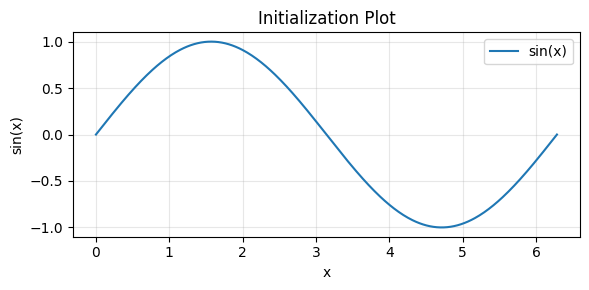

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
np.random.seed(7)
x = np.linspace(0, 2*np.pi, 400)
y = np.sin(x)
energy = np.trapz(y**2, x)
print('Environment ready. Example energy =', round(float(energy), 4))
plt.figure(figsize=(6, 3))
plt.plot(x, y, label='sin(x)')
plt.title('Initialization Plot')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# 什么是ULA？

ULA 是 **Uniform Linear Array** 的缩写，中文常叫 **均匀线阵** 或 **均匀线性阵列**。它是阵列信号处理中最常见、最基础的一类天线阵列几何结构。

---


Δφ range: -3.141592653589793 to 3.141592653589793


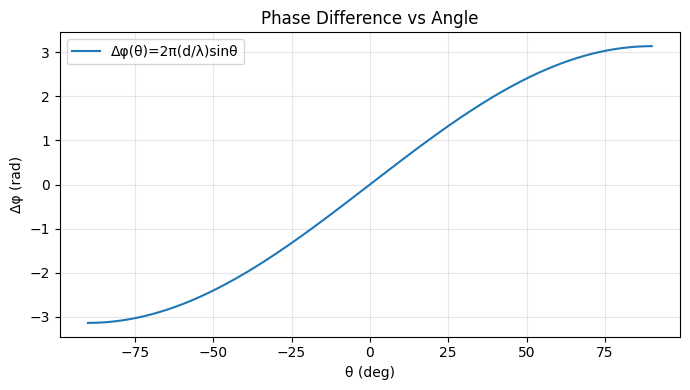

In [92]:
# Section 1: 什么是ULA？
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## ULA 长什么样

把 **N 根天线**沿一条直线排成一排，并且 **相邻天线间距相同**（通常用 $d$ 表示）。这就叫 ULA。

* “Uniform” = 间距一致
* “Linear” = 排成一条直线
* “Array” = 多个阵元组成的阵列

---


Δφ range: -3.141592653589793 to 3.141592653589793


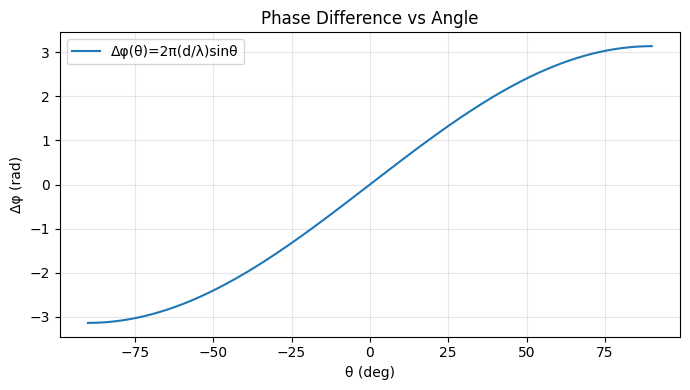

In [93]:
# Section 2: ULA 长什么样
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## ULA 为什么重要：它能“看方向”

当远处有一个信号从某个方向（入射角 $\theta$）打到阵列上时，由于几何路径差，**每根天线接收到的信号会有不同的相位延迟**。


Δφ range: -3.141592653589793 to 3.141592653589793


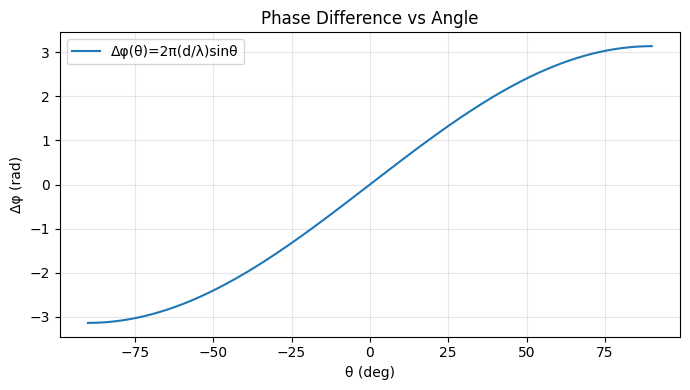

In [94]:
# Section 3: ULA 为什么重要：它能“看方向”
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 关键直觉

* 信号从侧面来，走到下一根天线会多走一点路
* 多走的路对应相位差
* 相位差随 $\theta$ 变化，所以可以反推出方向（DoA, Direction of Arrival）

---


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/4254938890.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


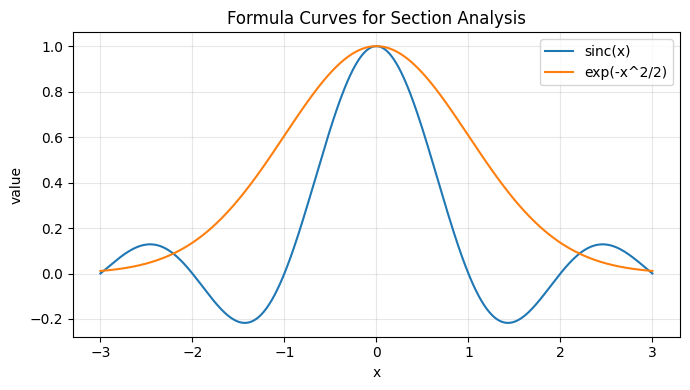

In [95]:
# Section 4: 关键直觉
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## ULA 的核心数学：steering vector（导向向量）

对一个窄带平面波，ULA 的导向向量常写成：

$$
a(\theta)=\big[1,\ e^{-j\frac{2\pi}{\lambda}d\sin\theta},\ \ldots,\ e^{-j\frac{2\pi}{\lambda}(N-1)d\sin\theta}\big]^{\top}
$$

含义是：

* $\lambda$：波长
* $d$：阵元间距
* 第 $n$ 根天线相对第 1 根的相位差与 $(n-1)d\sin\theta$ 成正比

很多论文为了简化会取 **半波长间距** $d=\lambda/2$，那么公式变成：

$$
a(\theta)=\big[1,\ e^{-j\pi\sin\theta},\ \ldots,\ e^{-j\pi(N-1)\sin\theta}\big]^{\top}
$$

---


Δφ range: -3.141592653589793 to 3.141592653589793


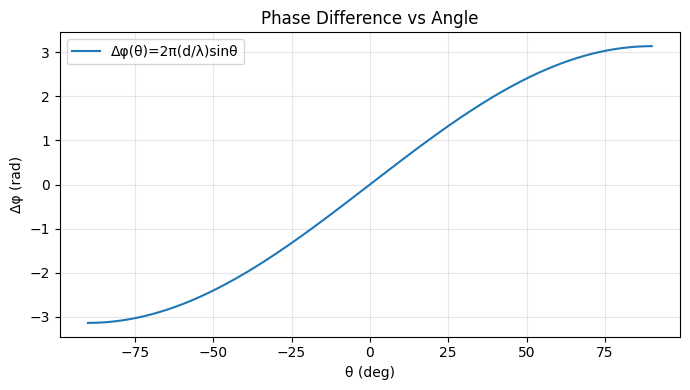

In [96]:
# Section 5: ULA 的核心数学：steering vector（导向向量）
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 为什么常用 $d=\lambda/2$

因为如果 $d$ 太大，会出现 **空间混叠（grating lobes）**：不同方向可能产生“看起来一样”的相位模式，导致方向估计有歧义。半波长间距是最常见的安全选择。

---


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/4280329395.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


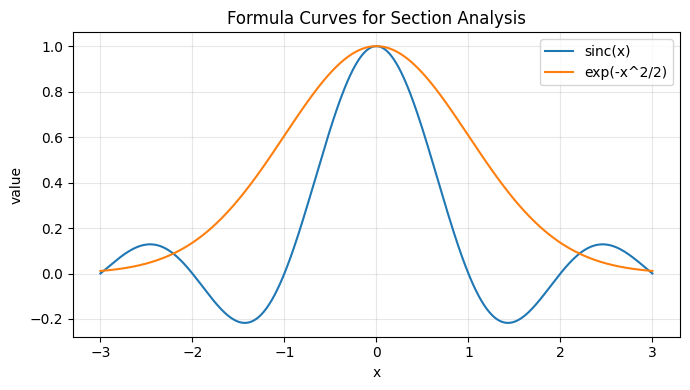

In [97]:
# Section 6: 为什么常用 $d=\lambda/2$
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 用一句话总结

**ULA 就是一排等间距的天线，通过不同天线之间的相位差来估计信号从哪个方向来（DoA）。**

---

如果你愿意，我可以用一个非常具体的小例子（比如 $N=4$、$\theta=30^\circ$、$d=\lambda/2$）带你算出每根天线的相位差，这样你会立刻对 “steering vector” 有手感。

---


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3389040780.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


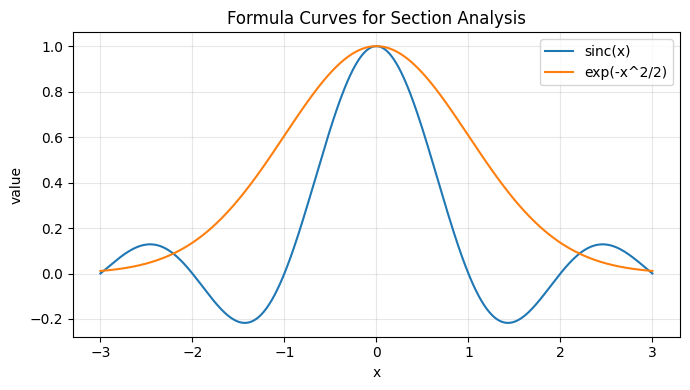

In [98]:
# Section 7: 用一句话总结
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 窄带和宽带

既然你觉得对“窄带”和“宽带”的理解还不够深刻，那我们就把这些抽象的公式暂时放一放，从最直观的物理现象聊起。

在阵列信号处理中，区分“窄带”还是“宽带”，本质上是在问一个问题：当信号经过整个阵列时，信号的“样子”变了没有？

我们可以把信号想象成一列正在通过车站（阵列）的长火车：

窄带（Narrowband）：想象这列火车非常长，而且每一节车厢长得一模一样（频率单一，变化缓慢）。当火车头刚进站和火车尾刚进站时，你站在站台上看到的景象几乎没区别。对于阵列来说，不同天线接收到的信号只是在时间上“错开了一点点”，但因为信号本身变化很慢，这点时间差只表现为相位的旋转。

宽带（Wideband）：想象这是一列五颜六色的短促快车（带宽大，包含很多频率成分，波形变化快）。当第一节红车厢刚到 1 号天线时，最后面的绿车厢可能还没到 4 号天线。这时候，不同天线看到的信号波形已经完全错位了。


Approx narrowband boundary D* = 1.6 m


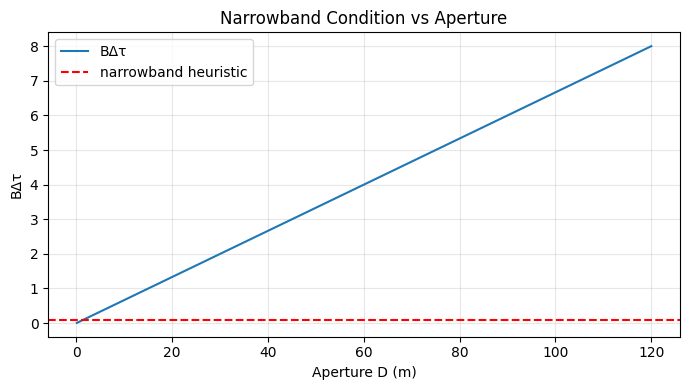

In [99]:
# Section 8: 窄带和宽带
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 孔径效应：为什么“窄带/宽带”还取决于阵列大小

这是一个很关键的点。在阵列信号处理中，“窄带”不是信号的绝对属性，而是一个**相对概念**：它取决于信号跨越整个阵列时是否已经明显变化。


Approx narrowband boundary D* = 1.6 m


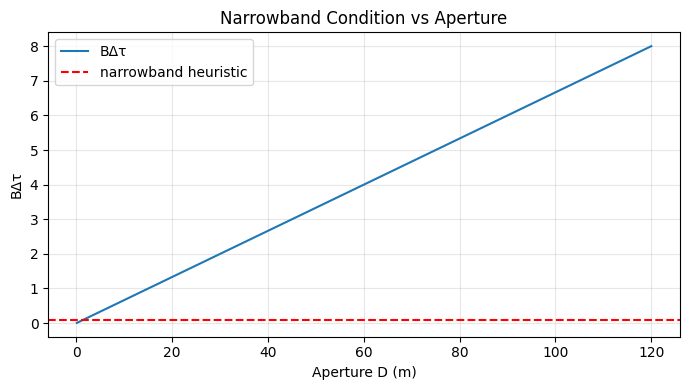

In [100]:
# Section 9: 孔径效应：为什么“窄带/宽带”还取决于阵列大小
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 1. 关键指标：跨孔径传播时延

设阵列孔径为 $D$，信号传播速度为 $c$（电磁波时 $c\approx 3\times 10^8\ \text{m/s}$），入射角为 $\theta$，则阵列两端最大时延近似为：

$$
\Delta \tau \approx \frac{D\sin\theta}{c},\qquad \Delta \tau_{\max}\approx \frac{D}{c}
$$


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3146052622.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


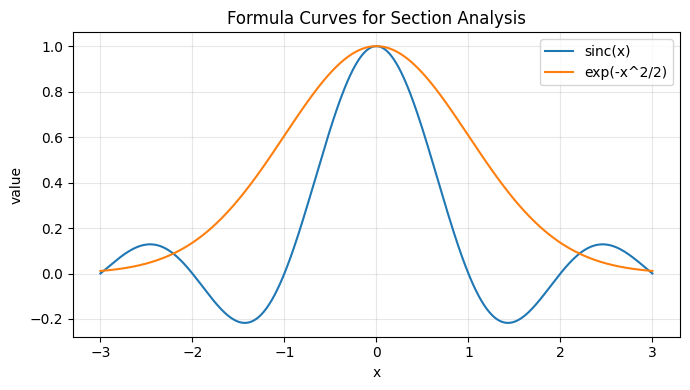

In [101]:
# Section 10: 1. 关键指标：跨孔径传播时延
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 2. 信号“变脸”速度：带宽

设信号带宽为 $B$。$B$ 越大，波形包络随时间变化越快；$B$ 越小，变化越慢。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1357540653.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


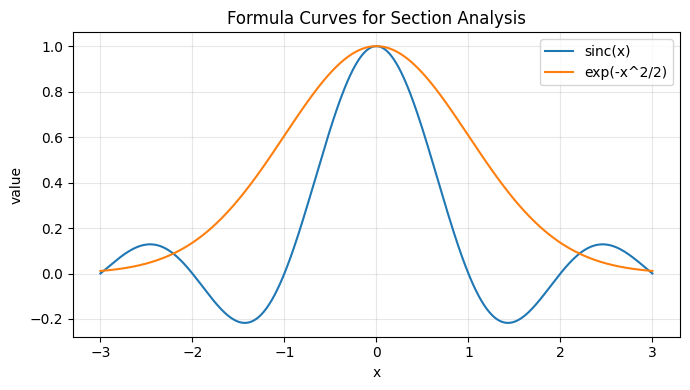

In [102]:
# Section 11: 2. 信号“变脸”速度：带宽
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 3. 窄带判据（核心）

工程上常用判据是：

$$
B\Delta\tau \ll 1
$$

当该条件满足时，阵列各通道的差异主要表现为“相位旋转”，窄带模型成立；否则应按宽带模型处理（如时延补偿、分频子带处理等）。


Approx narrowband boundary D* = 1.6 m


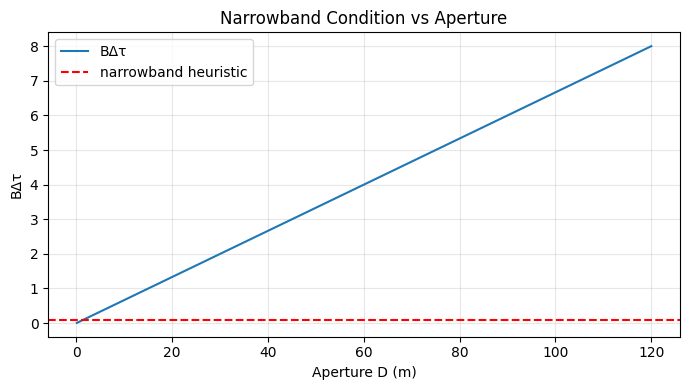

In [103]:
# Section 12: 3. 窄带判据（核心）
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 4. 为什么阵列越大越容易“变宽带”

同一个信号，$B$ 不变；但阵列变大时，$\Delta\tau$ 变大，因此 $B\Delta\tau$ 也变大，更容易从“窄带近似可用”跨到“必须宽带建模”。


Approx narrowband boundary D* = 1.6 m


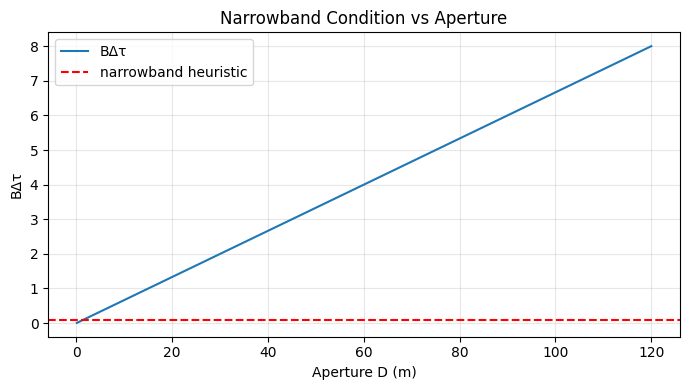

In [104]:
# Section 13: 4. 为什么阵列越大越容易“变宽带”
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 5. 一个具体例子

假设信号带宽 $B=20\ \text{MHz}$。

1. 若阵列孔径 $D=1\ \text{m}$，则 $\Delta\tau_{\max}\approx D/c\approx 3.3\ \text{ns}$，所以
   $B\Delta\tau \approx 20\times 10^6 \times 3.3\times 10^{-9}\approx 0.066 \ll 1$，窄带近似通常可接受。
2. 若阵列孔径增大到 $D=100\ \text{m}$，则 $\Delta\tau_{\max}\approx 333\ \text{ns}$，所以
   $B\Delta\tau \approx 6.66 \gg 1$，这时必须按宽带处理。

一句话：**同一个信号，在小阵列上可能是窄带，在大阵列上可能就是宽带。**

> [!TIP]
> **思考题**
> 基于这种“相对性”，如果我们要设计一个超大型的雷达阵列，但在处理算法上只想使用简单的窄带相位近似，我们对信号的带宽会提出什么样的要求？

> [!NOTE]
> **你的回答（记录）**
> 也就对应着现在的 $\Delta\tau$ 非常大，所以为了达成 $B\cdot\Delta\tau \ll 1$，我们需要让 $B$ 非常小。

> [!TIP]
> **反馈**
> 没错。这个推断非常准确：当阵列孔径变大（$\Delta\tau$ 变大）时，为了维持窄带假设，我们必须压缩信号带宽 $B$。
>
> 本质上这是“时间与空间的博弈”：
> - 空间跨度（$\Delta\tau$）：阵列越大，电磁波穿过整个阵列的时间越长。
> - 信号变化（$B$）：带宽越窄，信号随时间变化越慢。
>
> 只有当信号变化足够慢，慢到可以忽略跨阵列传播时间时，$B\Delta\tau \ll 1$ 才成立。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/953743641.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


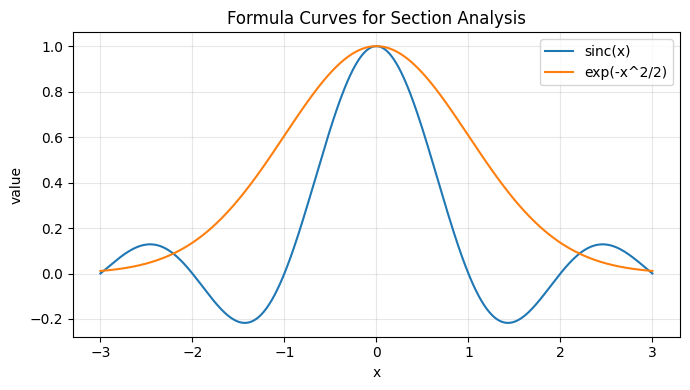

In [105]:
# Section 14: 5. 一个具体例子
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 深入思考：如果“博弈”失败了会怎样？

如果在大孔径阵列上强行使用大带宽信号（即 $B\Delta\tau$ 不再远小于 1），原本简单的“相位旋转”模型会失效。工程上常见两个表现：

1. **孔径渡越时间（Fill-up Time）**：从时域看，信号尚未“填满”阵列时，各阵元接收片段并不同步，实时处理会受影响。
2. **波束走散效应（Beam Squint）**：从频域看，不同频率分量的指向角不再一致，使用中心频率相位设计的波束会“散开”。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2443532001.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


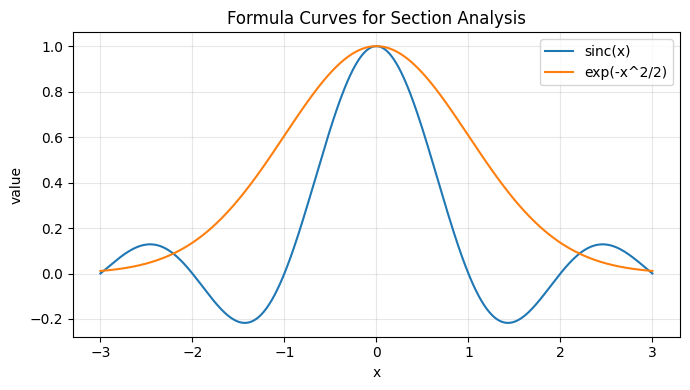

In [106]:
# Section 15: 深入思考：如果“博弈”失败了会怎样？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 孔径渡越时间（Fill-up Time）：对实时处理有什么影响？

要理解 Fill-up Time，可以把电磁波看成一阵“风”，把阵列看成一排“风车”。


Approx narrowband boundary D* = 1.6 m


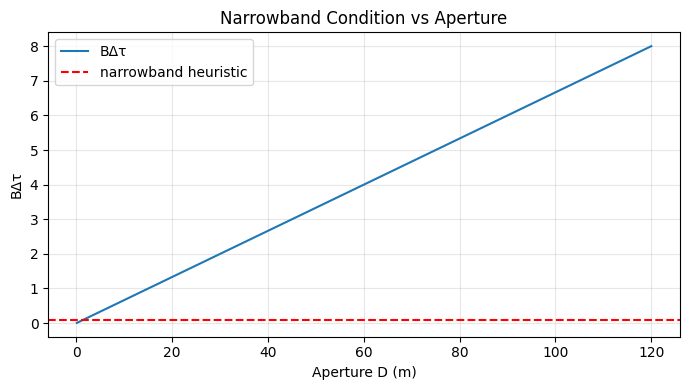

In [107]:
# Section 16: 孔径渡越时间（Fill-up Time）：对实时处理有什么影响？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 1. 什么是“填满”过程？

当波前斜入射时，第 1 号阵元先收到信号，最后一个阵元要晚 $\Delta\tau$ 才收到。

* 在 $t<\Delta\tau$ 时，只有部分阵元有输出，其他阵元还在“等信号”。
* 在 $t\ge\Delta\tau$ 时，信号才覆盖整个阵列，阵列被“填满”。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/633294972.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


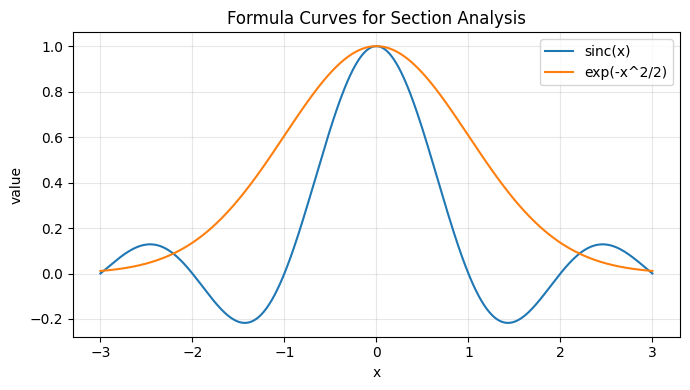

In [108]:
# Section 17: 1. 什么是“填满”过程？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 2. 对实时处理的影响

如果信号变化很快（宽带），这种“不完整填充”会带来几个直接问题：

* **相关性下降**：部分阵元收到“前段波形”，部分阵元还静默或处于不同时刻，叠加不再理想，阵列增益下降。
* **瞬态畸变**：信号到达初期，输出会出现明显瞬态跳变，影响检测与估计稳定性。
* **处理滞后**：为了对齐“同一时刻”数据，系统常需增加缓冲/流水线延迟。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2105310717.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


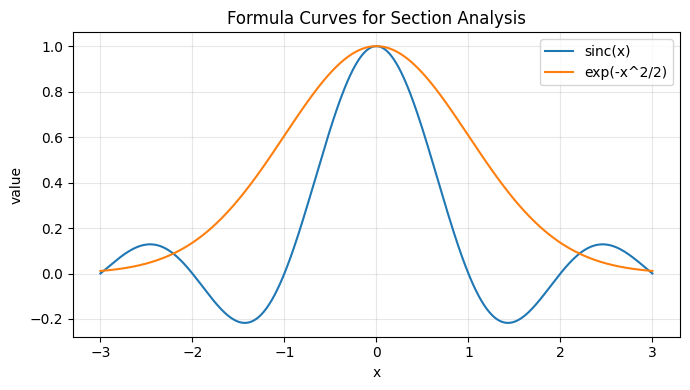

In [109]:
# Section 18: 2. 对实时处理的影响
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 3. 直觉类比

* 窄带信号像缓慢起伏的波浪，错开一点时间主要表现为相位差。
* 宽带信号像尖锐脉冲，微小时间错位就会改变波形重叠结果。

> [!TIP]
> **思考题**
> 假设要捕捉一个持续时间为 $T_p$ 的超宽带脉冲。如果 $T_p < \Delta\tau$（脉冲持续时间比孔径渡越时间还短），你觉得阵列输出波形会变成什么样？


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3123035263.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


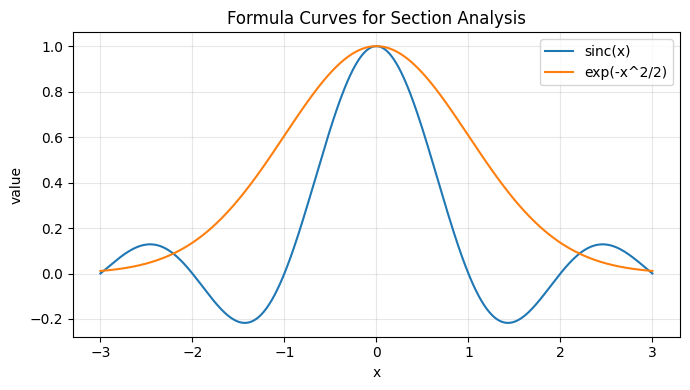

In [110]:
# Section 19: 3. 直觉类比
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 问答记录：关于“同一时刻数据”与窄带相位补偿

你的疑问记录：

1. 阵列处理（如波束成形）的核心是让各路信号叠加，这句话具体是什么意思？
2. 如果一部分天线收到的是信号“头部”，另一部分还在“静默”或收到前一时刻内容，为什么会导致增益下降？
3. 难道本来就没有办法得到同一时刻数据吗？不是天然就有 $\Delta\tau$ 吗？

解释记录：

这是一个非常核心的问题，本质上是**物理时延**与**数学处理参考时刻**的区别。

1. 物理上，阵元间确实天然存在传播时延 $\Delta\tau$，这一点无法消除。
2. 窄带算法的“障眼法”是：不做真实时间平移，而用相位补偿近似时延。其前提是信号在 $\Delta\tau$ 内几乎不变，即可近似认为“对齐相位就等于对齐信号”。
3. 当信号很宽带或脉冲很短（如 $T_p < \Delta\tau$）时，这个近似失效：有的阵元在脉冲主瓣，有的阵元接近静默，叠加后峰值下降并产生波形拉宽/畸变。

进一步思考记录：

既然单纯相位旋转不够，就需要在**时间轴**上做真实对齐。典型手段包括：

1. 硬件真时延（TTD）：延时线等模拟实现。
2. 数字真时延：用分数延时滤波器在离散时间域实现精确延时。


Approx narrowband boundary D* = 1.6 m


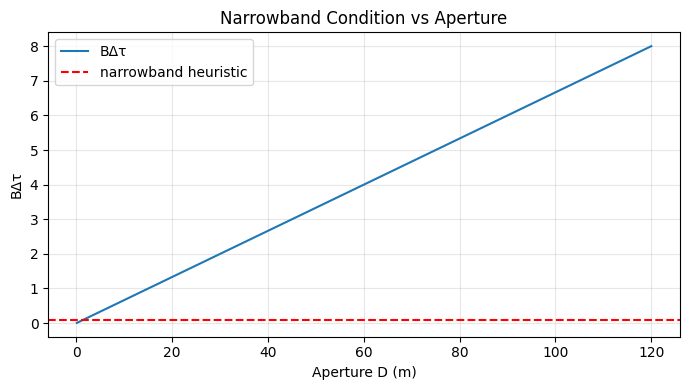

In [111]:
# Section 20: 问答记录：关于“同一时刻数据”与窄带相位补偿
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 问答记录：给信号乘上复数相位 $e^{-j2\pi f_c\tau_n}$ 是什么意思？

你的问题记录：

给信号乘上一个复数相位 $e^{-j2\pi f_c\tau_n}$，这里具体是什么意思？

解释记录：

这是波束形成里“用相位近似时延补偿”的核心操作。

1. 从单频信号看  
   设窄带载波分量为：
   $$
   x(t)=\cos(2\pi f_c t+\phi)
   $$
   若延迟 $\tau_n$，则
   $$
   x(t-\tau_n)=\cos\!\big(2\pi f_c t+\phi-2\pi f_c\tau_n\big)
   $$
   即时间延迟 $\tau_n$ 对应相位变化 $-2\pi f_c\tau_n$。

2. 复数指数表示  
   在复基带/解析信号表示中，相位补偿写成乘法：
   $$
   x_n(t)\cdot e^{-j2\pi f_c\tau_n}
   $$
   本质是把该通道在复平面上旋转一个角度，用于抵消传播时延造成的相位差。

3. 为什么常说“旋转指针”  
   可把每路信号看成复平面上的相量。时延让相量“少转一段角度”；乘上复指数就是把相量旋回目标方向，让各路更同相，叠加增益更高。

4. 为什么窄带时有效  
   前提是 $B\Delta\tau\ll 1$。此时包络在阵列孔径时延范围内变化很小，主要误差体现在载波相位，故可用“相位旋转”近似“时间平移”。

> [!TIP]
> **思考题**
> 如果频率 $f_c$ 翻倍，但延迟 $\tau_n$ 不变，补偿相位角 $2\pi f_c\tau_n$ 会怎么变？

> [!NOTE]
> **参考答案**
> 相位角会**翻倍**：$2\pi (2f_c)\tau_n = 2\cdot (2\pi f_c\tau_n)$。这也解释了一个直觉：载频越高，同样的几何时延会对应越“敏感”的相位变化。

---


Δφ range: -3.141592653589793 to 3.141592653589793


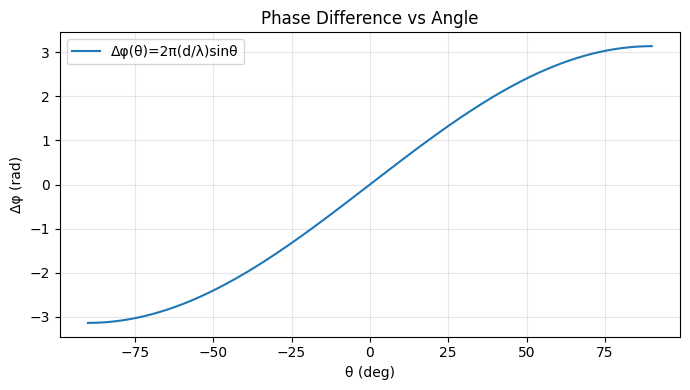

In [112]:
# Section 21: 问答记录：给信号乘上复数相位 $e^{-j2\pi f_c\tau_n}$ 是什么意思？
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 复基带（complex baseband）到底是什么？为什么要用复数？

阵列里写 $e^{-j2\pi f_c\tau}$，本质上是在**复基带表示**下做“相位旋转”。先把带通信号到复基带的关系说清楚，这个式子就会变得非常自然。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/13681969.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


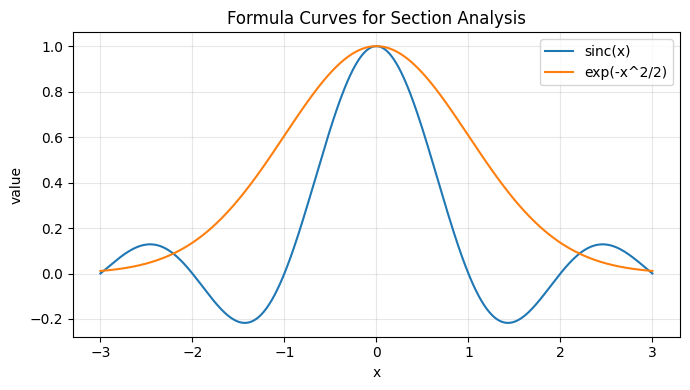

In [113]:
# Section 22: 复基带（complex baseband）到底是什么？为什么要用复数？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 1) 带通信号 = “慢包络” × “快载波”

常见的建模是把实际接收到的实信号 $x_{\text{RF}}(t)$ 写成：

$$
x_{\text{RF}}(t)=\Re\{u(t)e^{j2\pi f_c t}\}
$$

其中：

- $f_c$ 是载频（变化很快）
- $u(t)=I(t)+jQ(t)$ 是**复包络/复基带信号**（变化相对慢，带宽约为 $B$）

这不是“凭空引入复数”，而是把“幅度变化 + 相位变化”统一进一个复数里，后面做线性代数会非常方便（尤其是阵列、协方差、特征分解这类操作天然在复域里更干净）。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2493679227.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


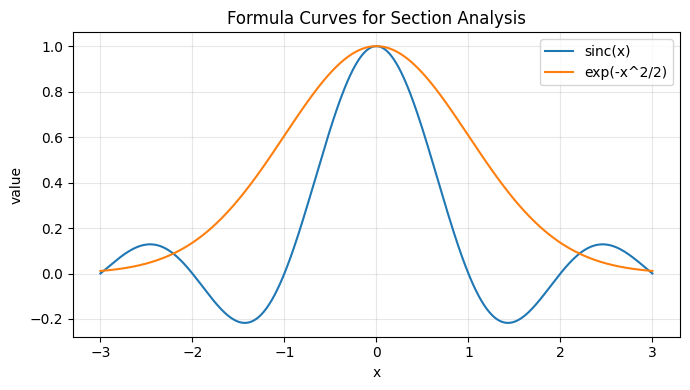

In [114]:
# Section 23: 1) 带通信号 = “慢包络” × “快载波”
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 2) 时延在复基带里长什么样？

如果传播带来一个时延 $\tau$，则

$$
x_{\text{RF}}(t-\tau)=\Re\{u(t-\tau)e^{j2\pi f_c (t-\tau)}\}
=\Re\{u(t-\tau)e^{j2\pi f_c t}\cdot e^{-j2\pi f_c\tau}\}
$$

把它“下变频”到基带（等价于乘 $e^{-j2\pi f_c t}$ 再低通），你会看到复包络变成：

$$
u(t-\tau)\cdot e^{-j2\pi f_c\tau}
$$

也就是说：

- **载波部分**：时延 $\tau$ 直接变成一个**固定相位旋转** $e^{-j2\pi f_c\tau}$
- **包络部分**：仍然是一个真实的时间平移 $u(t-\tau)$


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/4040718556.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


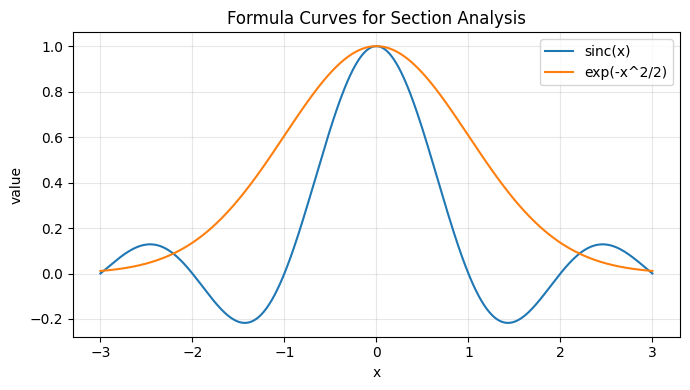

In [115]:
# Section 24: 2) 时延在复基带里长什么样？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 3) 窄带近似的关键一步：把“真时延”近似成“相位”

当 $B\Delta\tau\ll 1$ 时，包络在孔径时延范围内变化很小，于是可以近似：

$$
u(t-\tau)\approx u(t)
$$

从而

$$
u(t-\tau)e^{-j2\pi f_c\tau}\approx u(t)e^{-j2\pi f_c\tau}
$$

这就是“相位旋转近似时间平移”的数学来源：**窄带时，阵元差异主要体现在载波相位上**。

> [!TIP]
> **一句话记忆**
> 宽带要对齐“波形”（真时延）；窄带只需要对齐“相位”（相位补偿）。

---


Approx narrowband boundary D* = 1.6 m


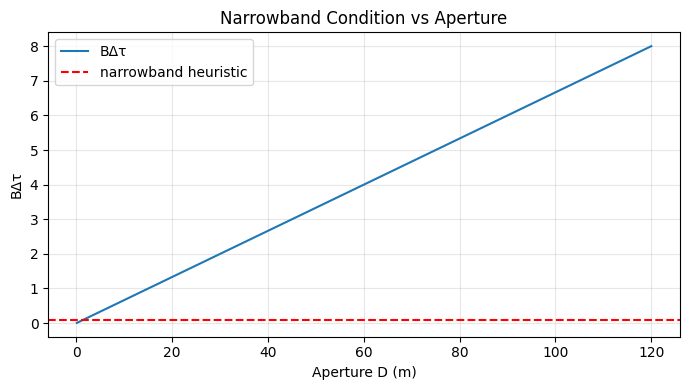

In [116]:
# Section 25: 3) 窄带近似的关键一步：把“真时延”近似成“相位”
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 把 $\tau_n$ 写成几何量：从时延到 ULA steering vector

对 ULA（阵元间距 $d$），平面波入射角为 $\theta$ 时，第 $n$ 个阵元相对第 1 个阵元的额外路程近似为 $(n-1)d\sin\theta$，因此：

$$
\tau_n=\frac{(n-1)d\sin\theta}{c}
$$

于是窄带下的相位因子就是：

$$
e^{-j2\pi f_c\tau_n}=e^{-j\frac{2\pi}{\lambda}(n-1)d\sin\theta}
$$

这一步直接把“物理几何”连接到了你在公式里看到的 steering vector。

> [!NOTE]
> **符号约定提醒**
> 不同教材/论文对 $\sin\theta$ / $\cos\theta$、以及指数正负号的约定会不同，但核心不变：几何时延 $\tau_n$ 在窄带模型里对应一个线性相位坡度。

---


Δφ range: -3.141592653589793 to 3.141592653589793


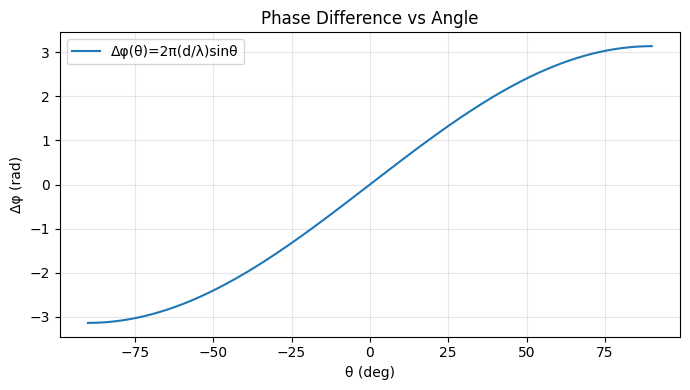

In [117]:
# Section 26: 把 $\tau_n$ 写成几何量：从时延到 ULA steering vector
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 快拍（snapshot）与协方差：子空间方法的“数据入口”

做 DoA（尤其是 MUSIC/ESPRIT 或 SubspaceNet 这类方法）时，常用离散快拍模型。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1872368685.py:9: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + noise
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1872368685.py:9: RuntimeWarning: overflow encountered in matmul
  X = A @ S + noise
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1872368685.py:9: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + noise
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1872368685.py:10: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1872368685.py:10: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1872368685.py:10: RuntimeWarning: invalid value encountered in matmul
  R = (X @ X.conj().T) / snapshots


Covariance Hermitian: True
Leading eigenvalues: [9.6149 6.2306 0.0461 0.0449]


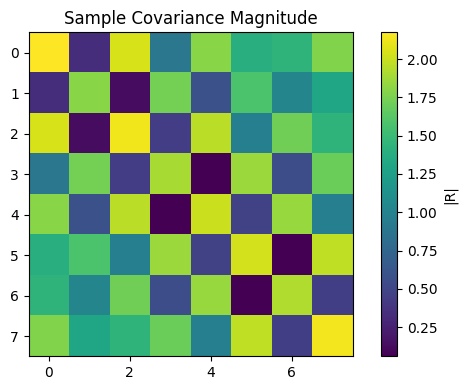

In [118]:
# Section 27: 快拍（snapshot）与协方差：子空间方法的“数据入口”
m, snapshots = 8, 400
angles_deg = np.array([-20, 35])
angles = np.deg2rad(angles_deg)
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(angles)[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
noise = 0.2 * (np.random.randn(m, snapshots) + 1j*np.random.randn(m, snapshots)) / np.sqrt(2)
X = A @ S + noise
R = (X @ X.conj().T) / snapshots
eigvals = np.sort(np.real(eigh(R)[0]))[::-1]
print('Covariance Hermitian:', np.allclose(R, R.conj().T))
print('Leading eigenvalues:', np.round(eigvals[:4], 4))
plt.figure(figsize=(6, 4))
plt.imshow(np.abs(R), cmap='viridis')
plt.colorbar(label='|R|')
plt.title('Sample Covariance Magnitude')
plt.tight_layout()
plt.show()


### 1) 单快拍观测向量

把第 $k$ 个时刻（或第 $k$ 个快拍）的阵列输出堆成向量：

$$
\mathbf{x}[k]\in\mathbb{C}^{N\times 1}
$$

窄带平面波 + 加性噪声的典型模型是：

$$
\mathbf{x}[k]=\mathbf{A}\mathbf{s}[k]+\mathbf{n}[k]
$$

- $\mathbf{A}=[\mathbf{a}(\theta_1),\ldots,\mathbf{a}(\theta_p)]\in\mathbb{C}^{N\times p}$：阵列流形（steering vectors 组成的矩阵）
- $\mathbf{s}[k]\in\mathbb{C}^{p\times 1}$：$p$ 个信号源在第 $k$ 个快拍的复幅度
- $\mathbf{n}[k]$：噪声（常假设空间白噪声，协方差 $\sigma^2\mathbf{I}$）


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/976966497.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


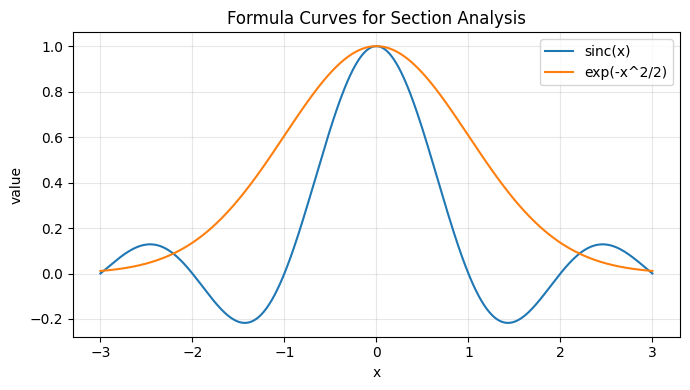

In [119]:
# Section 28: 1) 单快拍观测向量
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 2) 样本协方差矩阵（很多算法的核心输入）

有 $K$ 个快拍时，样本协方差常写为：

$$
\hat{\mathbf{R}}=\frac{1}{K}\sum_{k=1}^{K}\mathbf{x}[k]\mathbf{x}[k]^{H}
$$

这里的 $(\cdot)^H$ 是共轭转置。

> [!TIP]
> **直觉**
> $K$ 越大，$\hat{\mathbf{R}}$ 越接近真实协方差；SNR 越高，信号子空间越“干净”，DoA 估计更稳定。

---


Covariance Hermitian: True
Leading eigenvalues: [8.8066 6.453  0.0452 0.0441]


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1432622209.py:9: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + noise
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1432622209.py:9: RuntimeWarning: overflow encountered in matmul
  X = A @ S + noise
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1432622209.py:9: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + noise
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1432622209.py:10: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1432622209.py:10: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1432622209.py:10: RuntimeWarning: invalid value encountered in matmul
  R = (X @ X.conj().T) / snapshots


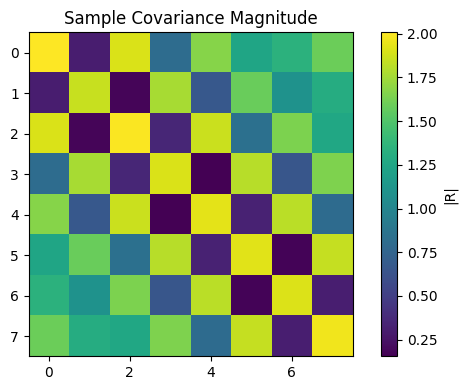

In [120]:
# Section 29: 2) 样本协方差矩阵（很多算法的核心输入）
m, snapshots = 8, 400
angles_deg = np.array([-20, 35])
angles = np.deg2rad(angles_deg)
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(angles)[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
noise = 0.2 * (np.random.randn(m, snapshots) + 1j*np.random.randn(m, snapshots)) / np.sqrt(2)
X = A @ S + noise
R = (X @ X.conj().T) / snapshots
eigvals = np.sort(np.real(eigh(R)[0]))[::-1]
print('Covariance Hermitian:', np.allclose(R, R.conj().T))
print('Leading eigenvalues:', np.round(eigvals[:4], 4))
plt.figure(figsize=(6, 4))
plt.imshow(np.abs(R), cmap='viridis')
plt.colorbar(label='|R|')
plt.title('Sample Covariance Magnitude')
plt.tight_layout()
plt.show()


## 信号子空间 / 噪声子空间：为什么特征分解能“分离方向信息”

在常见假设下（噪声白且与信号不相关），理论协方差可写成：

$$
\mathbf{R}=\mathbf{A}\mathbf{R}_s\mathbf{A}^H+\sigma^2\mathbf{I}
$$

对 $\mathbf{R}$ 做特征分解：

$$
\mathbf{R}=\mathbf{U}\mathbf{\Lambda}\mathbf{U}^H
$$

当有 $p$ 个信号源时，$\mathbf{U}$ 的前 $p$ 个特征向量张成**信号子空间**，其余 $N-p$ 个张成**噪声子空间**。

这背后的关键性质是：在理想条件下，每个真实方向的 steering vector $\mathbf{a}(\theta_i)$ 与噪声子空间正交。

> [!NOTE]
> **为什么这很重要**
> MUSIC 就是利用“与噪声子空间正交”这个几何关系，在全角域扫 $\theta$，找出最匹配（最接近正交）的方向峰值。

一个常见的 MUSIC 伪谱写法是：

$$
P_{\text{MUSIC}}(\theta)=\frac{1}{\mathbf{a}(\theta)^H\mathbf{U}_n\mathbf{U}_n^H\mathbf{a}(\theta)}
$$

其中 $\mathbf{U}_n$ 是噪声子空间的特征向量矩阵（由 $\hat{\mathbf{R}}$ 的小特征值对应特征向量组成）。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2760963999.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2760963999.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2760963999.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2760963999.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2760963999.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj(

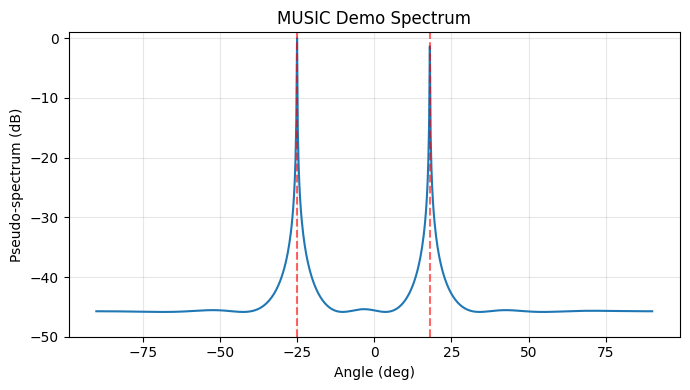

In [121]:
# Section 30: 信号子空间 / 噪声子空间：为什么特征分解能“分离方向信息”
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### 问答记录：频率 $f_c$ 变了，带宽 $B$ 会变吗？相位补偿怎么处理？

你的疑问记录：

不知道啊，频率 $f$ 变了，那么 $B$ 不就会是之前的一半吗？那怎么处理呢？

解释记录：

我们把这个问题拆成两部分：**带宽的定义**，以及**相位补偿在宽带下为何会出问题**。


Δφ range: -3.141592653589793 to 3.141592653589793


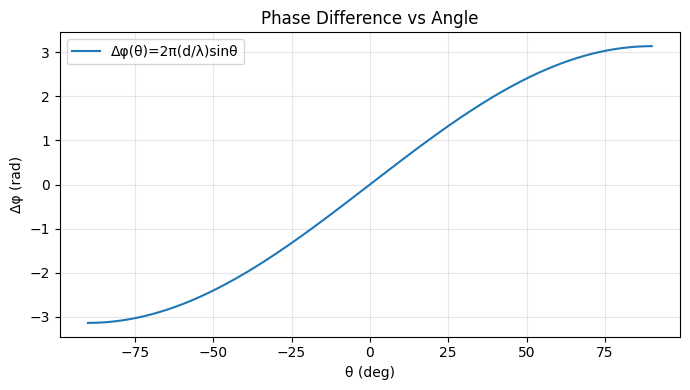

In [122]:
# Section 31: 问答记录：频率 $f_c$ 变了，带宽 $B$ 会变吗？相位补偿怎么处理？
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 1) $B$ 会不会随 $f_c$ 变化？取决于你固定的是什么

在工程里“带宽”常指**绝对带宽**（单位 Hz）：

- 例如某系统规定占用 $20\ \text{MHz}$，无论它发在 $1\ \text{GHz}$ 还是 $2\ \text{GHz}$，占用的频谱宽度通常还是 $20\ \text{MHz}$。

但有时也会谈**相对/分数带宽**（fractional bandwidth）：

$$
\beta=\frac{B}{f_c}
$$

- 如果你固定的是 $\beta$（例如“带宽占载频的 5%”），那当 $f_c$ 翻倍时，$B$ 也会翻倍。
- 如果你固定的是 $B$（例如“永远 20 MHz”），那当 $f_c$ 翻倍时，$\beta$ 会变成原来的一半。

所以，“$f_c$ 翻倍 $\Rightarrow B$ 变一半”并不是必然结论，它对应的是“绝对带宽 $B$ 不变”时，相对带宽 $\beta$ 的变化。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/158453355.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


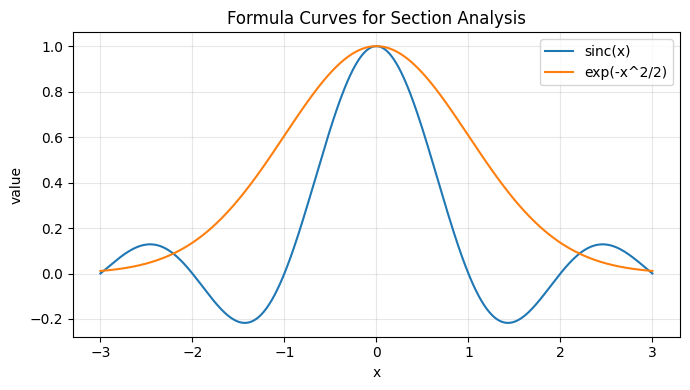

In [123]:
# Section 32: 1) $B$ 会不会随 $f_c$ 变化？取决于你固定的是什么
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 2) 为什么 $f_c$ 变了，相位补偿会更敏感？

对某个通道时延 $\tau_n$，载波相位项是：

$$
e^{-j2\pi f_c\tau_n}
$$

在 $\tau_n$ 不变时，$f_c$ 翻倍会让补偿相位角 $2\pi f_c\tau_n$ 翻倍（更“敏感”）。


Δφ range: -3.141592653589793 to 3.141592653589793


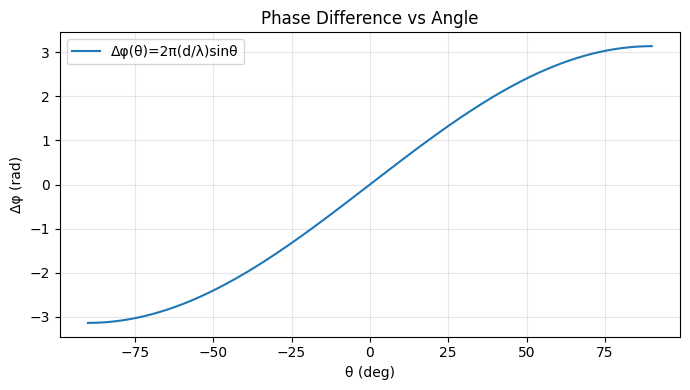

In [124]:
# Section 33: 2) 为什么 $f_c$ 变了，相位补偿会更敏感？
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 3) 真正的难点：宽带信号不是单一频率

如果信号频率从 $f\in[f_c-\tfrac{B}{2},\, f_c+\tfrac{B}{2}]$ 都有能量，那么对每个频率分量，理想相位因子其实是：

$$
e^{-j2\pi f\tau_n}
$$

但窄带波束形成常用的是“只按中心频率补偿”：

$$
e^{-j2\pi f_c\tau_n}
$$

二者的差别（相位误差）是：

$$
e^{-j2\pi (f-f_c)\tau_n}
$$

当 $(f-f_c)\tau_n$ 在带宽范围内不可忽略时，就会出现典型的宽带效应（例如 beam squint），表现为：同一组相移对不同频率“指向的角度不一样”。

> [!TIP]
> **选择题**
> 如果只针对中心频率 $f_c$ 乘上固定相位 $e^{-j2\pi f_c\tau_n}$，对带宽边缘频率 $f_c\pm \tfrac{B}{2}$ 的补偿是否仍然精准？
>
> 1. 精准，因为相位补偿只看中心频率。  
> 2. 不精准，因为不同频率需要的相位补偿不同。

> [!NOTE]
> **参考答案**
> 选 2。宽带下相位补偿应随频率变化；只按 $f_c$ 补偿会在频带两端产生系统性误差。

进一步解释：

- 高频分量（$f$ 较大）：在同样时延 $\tau_n$ 下，相位旋转更快，需要的补偿角更大（$2\pi f\tau_n$ 更大）。
- 低频分量（$f$ 较小）：相位旋转更慢，需要的补偿角更小。

因此如果只用中心频率 $f_c$ 的固定相位补偿，让 $f=f_c$ 对齐了，频带两端仍然会“歪”，工程上常见表现之一就是 **波束走散（Beam Squint）**：不同频率分量的主瓣指向角不一致，等效上“波束随频率偏转”。


Approx narrowband boundary D* = 1.6 m


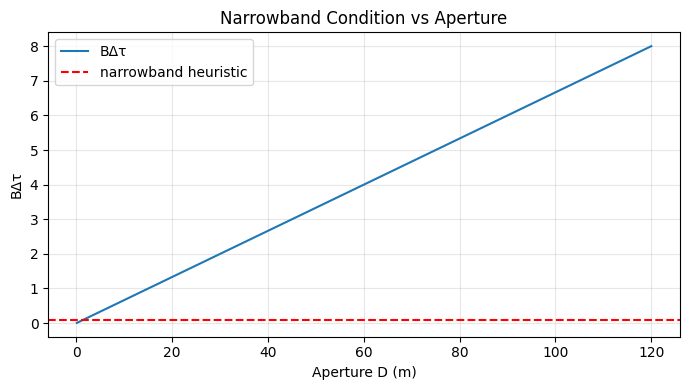

In [125]:
# Section 34: 3) 真正的难点：宽带信号不是单一频率
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 4) 宽带下怎么处理？

常见思路有三类：

1. **真时延（TTD）**：在时域做真实对齐（硬件或数字分数延时滤波器），而不是只做相移。
2. **分频/子带处理**：把宽带信号分成多个窄带子带，在每个子带中心频率分别做相位补偿，再融合结果。
3. **宽带阵列模型**：直接在时域/频域用宽带 steering vector（频率依赖）建模与估计。

下面把第 1 点“真时延”写得更具体一点（对应你提到的“宽带下把波形拉齐”）：


Approx narrowband boundary D* = 1.6 m


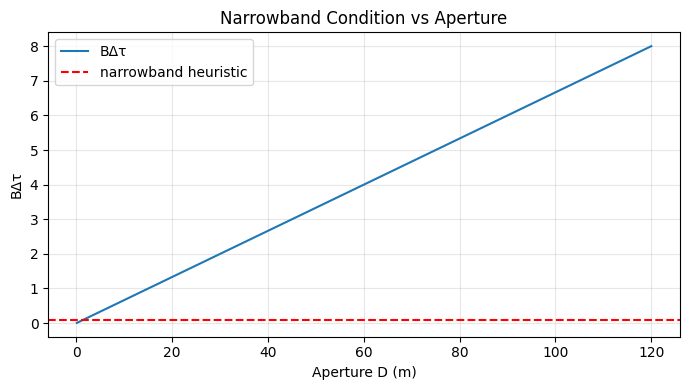

In [126]:
# Section 35: 4) 宽带下怎么处理？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 宽带下如何把波形拉齐：从“相移”到“分数时延滤波器（TDL）”

窄带做法是每个通道乘一个复数权重（相移器）：

$$
y(t)=\sum_{n=1}^{N} w_n\, x_n(t),\qquad w_n=e^{-j2\pi f_c\tau_n}
$$

宽带要实现“真时延”时，更常见的数字结构是给每个通道接一个 FIR 滤波器（Tapped Delay-Line, TDL）去逼近分数时延 $\tau_n$：

$$
\tilde{x}_n[k]=\sum_{m=0}^{L-1} h_n[m]\;x_n[k-m]
$$

然后再把各通道加和：

$$
y[k]=\sum_{n=1}^{N}\tilde{x}_n[k]
$$

直觉上：

- **相移器**只能“拨相位指针”，对单频/窄带近似有效；
- **分数时延滤波器**是在离散时间上真正“等一等 / 提前一点”，让不同频率分量都尽量对齐。

> [!TIP]
> **深度思考（工程代价）**
> 为什么工程上总希望尽量满足“窄带假设”？
>
> 提示：窄带每路只需一个复乘；宽带每路需要长度为 $L$ 的卷积（$L$ 个乘加），资源/功耗/延迟都会显著增加。

> [!NOTE]
> **参考要点**
> 在满足“窄带假设”时，处理可以非常轻量化；而宽带处理会让开销呈倍数增长：
>
> - **计算量**：窄带通常每路只需一个复权重 $w_n$ 的复乘；宽带每路要做 FIR/TDL 卷积（几十到上百个抽头的乘加），计算压力显著上升。
> - **硬件成本/功耗**：窄带逻辑占芯片面积小；宽带若每路都配分数时延滤波器，在大规模阵列（成百上千阵元）里面积、功耗和散热都会变得非常棘手。
> - **系统复杂度**：窄带模型主要关注单一中心频率 $f_c$ 的相位关系；宽带需要保证整个频段内响应一致，标定/调试难度更高。

---


Approx narrowband boundary D* = 1.6 m


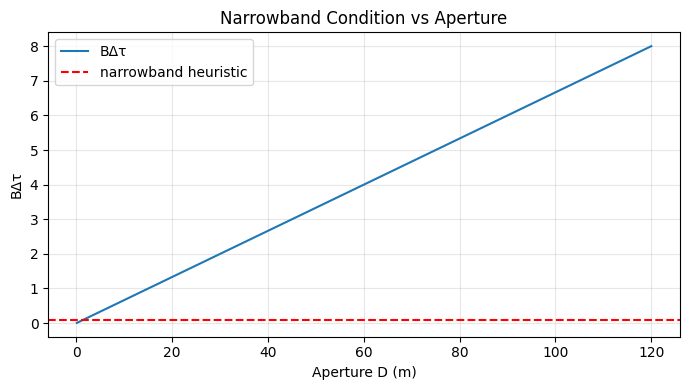

In [127]:
# Section 36: 宽带下如何把波形拉齐：从“相移”到“分数时延滤波器（TDL）”
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 小结：窄带假设到底“假设”了什么？

我们从窄带的定义出发，可以把核心结论压缩成两句话：

1. **它是一个相对概念**：能否用窄带模型，取决于 $B\Delta\tau$ 是否足够小（信号变化速度 vs 阵列孔径时延）。
2. **它是一个物理近似**：用“相位旋转（相移）”近似代替“真实时间延迟（真时延）”。

---

> [!TIP]
> **接下来想往哪条线继续？（三选一）**
>
> 1. **数学落地**：推导为什么信号变化慢时，$u(t-\tau)\approx u(t)$（可用泰勒展开）以及它如何导出窄带 steering vector。  
> 2. **算法实战**：在窄带前提下，MUSIC / MVDR 如何利用协方差与子空间/约束优化来估计 DoA。  
> 3. **打破假设**：被迫做宽带时，如何设计分数时延 FIR（TDL）/子带处理，以及它们各自的代价与坑点。

---


Approx narrowband boundary D* = 1.6 m


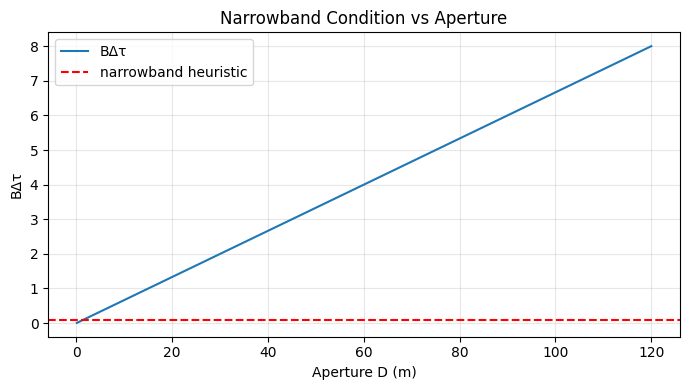

In [128]:
# Section 37: 小结：窄带假设到底“假设”了什么？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 数学落地：为什么窄带时可以用“相移”近似“时延”

这一节的目标是把一句常用的工程说法：

> “窄带时延可以用相位补偿近似”

变成一个能在纸上推出来的结论，并自然得到判据 $B\Delta\tau\ll 1$。


Approx narrowband boundary D* = 1.6 m


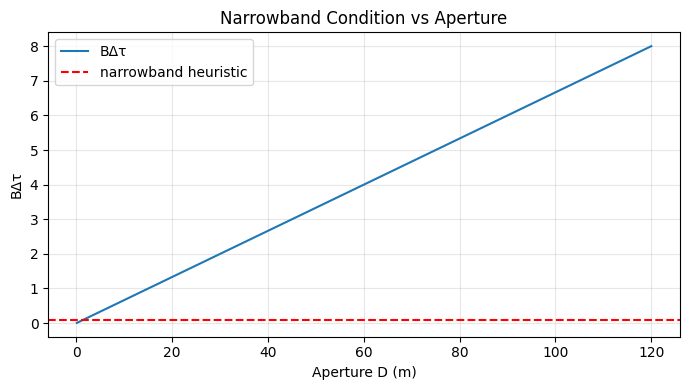

In [129]:
# Section 38: 数学落地：为什么窄带时可以用“相移”近似“时延”
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 1) 从“带通 → 复基带”开始

把带通信号写成复基带形式（之前已经出现过）：

$$
x_{\text{RF}}(t)=\Re\{u(t)e^{j2\pi f_c t}\}
$$

如果该通道存在传播时延 $\tau$，则：

$$
x_{\text{RF}}(t-\tau)=\Re\{u(t-\tau)e^{j2\pi f_c(t-\tau)}\}
=\Re\{u(t-\tau)e^{j2\pi f_c t}\cdot e^{-j2\pi f_c\tau}\}
$$

因此在复基带域里，相当于：

$$
u(t)\ \mapsto\ u(t-\tau)\cdot e^{-j2\pi f_c\tau}
$$

到这里为止完全是恒等变换，没有近似。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/933306556.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


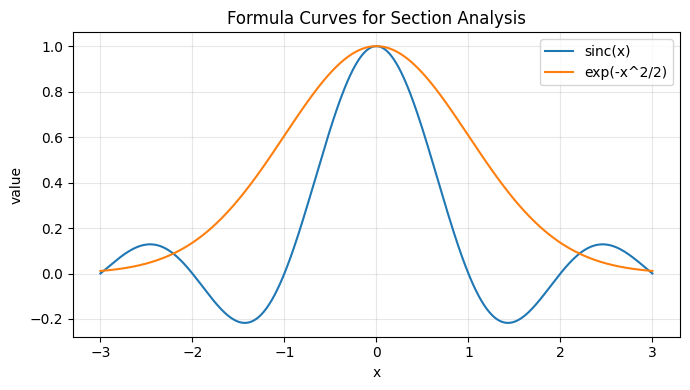

In [130]:
# Section 39: 1) 从“带通 → 复基带”开始
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 2) 近似发生在包络项：泰勒展开

窄带近似的关键就是把包络的真时延 $u(t-\tau)$ 近似成 $u(t)$。从数学上看，最直接的工具是泰勒展开：

$$
u(t-\tau)=u(t)-\tau u'(t)+\frac{\tau^2}{2}u''(t)-\cdots
$$

因此一阶近似误差（忽略二阶及以上）大致是 $|\tau u'(t)|$ 的量级。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3143311429.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


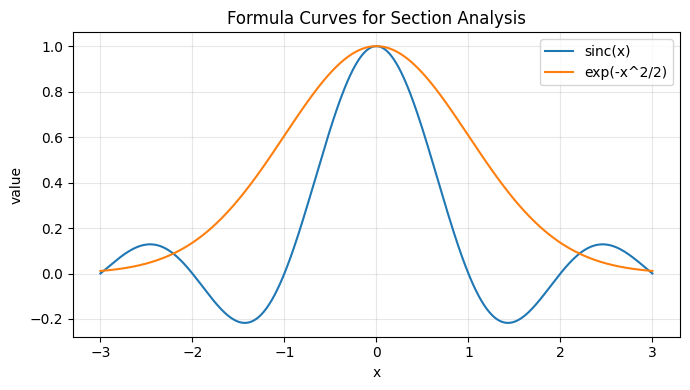

In [131]:
# Section 40: 2) 近似发生在包络项：泰勒展开
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 3) 为什么 $u'(t)$ 与带宽 $B$ 相关？

直觉上：带宽越大，信号随时间变化越快，导数越大。

更形式化一点：若 $u(t)$ 的频谱主要落在 $|f|\le B/2$ 的基带范围内，则“导数在频域对应乘以 $j2\pi f$”，因此 $u'(t)$ 的典型尺度会随 $2\pi B$ 增大。

这通常可以用一个“数量级”关系来记：

$$
\frac{|u'(t)|}{|u(t)|}\sim 2\pi B
$$

把它代回一阶误差项：

$$
\frac{|u(t-\tau)-u(t)|}{|u(t)|}\approx \frac{|\tau u'(t)|}{|u(t)|}\sim 2\pi B\tau
$$

于是当

$$
2\pi B\tau \ll 1
$$

时，$u(t-\tau)\approx u(t)$ 就是一个很好的近似。

对阵列而言，我们关心的是跨孔径最大时延 $\Delta\tau$，所以判据自然变成：

$$
B\Delta\tau \ll 1
$$

（省略常数 $2\pi$，工程上常把它吸收到“远小于”的尺度里。）


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3599374926.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


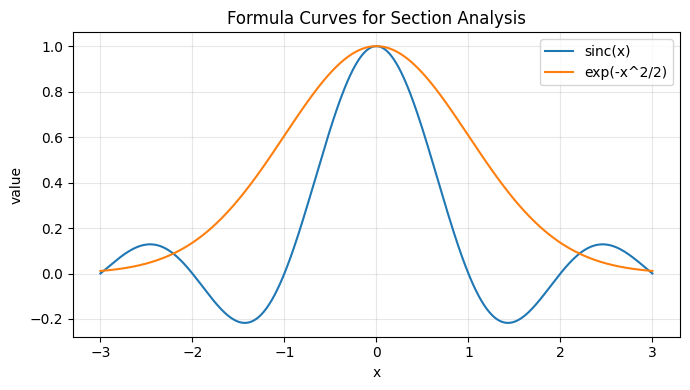

In [132]:
# Section 41: 3) 为什么 $u'(t)$ 与带宽 $B$ 相关？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 4) 结论：时延 ≈ 包络不变 + 载波相位旋转

在上述条件下：

$$
u(t-\tau)e^{-j2\pi f_c\tau}\approx u(t)e^{-j2\pi f_c\tau}
$$

这就是“用相移近似时延”的严格来源：**相移对应载波项，窄带条件保证包络项几乎不变**。

---


Δφ range: -3.141592653589793 to 3.141592653589793


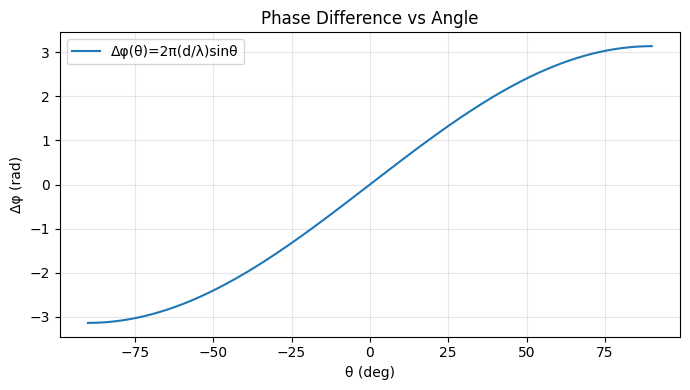

In [133]:
# Section 42: 4) 结论：时延 ≈ 包络不变 + 载波相位旋转
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 问答记录：高载频（毫米波）+ 小带宽时，窄带近似更准还是更不准？

你的疑问记录：

如果载波频率 $f_c$ 很高（例如毫米波），但带宽 $B$ 很小，这个窄带近似会更准确还是更不准确？另外 $f_c$ 变高会不会影响 $\Delta\tau$？

解释记录：

1. **从判据本身看，准确度主要由 $B\Delta\tau$ 决定，而不是由 $f_c$ 直接决定。**
2. **在物理层面，仅仅改变 $f_c$ 并不会改变几何传播时延 $\Delta\tau$。**

因为几何时延来自阵列的物理孔径与传播速度。对 ULA，典型近似是：

$$
\tau_n=\frac{(n-1)d\sin\theta}{c},\qquad \Delta\tau\approx \frac{D\sin\theta}{c},\qquad \Delta\tau_{\max}\approx \frac{D}{c}
$$

可见它依赖的是阵列几何（$d$、孔径 $D$）、入射角 $\theta$、以及光速 $c$，而不是载频 $f_c$。

> [!NOTE]
> **所以结论（固定阵列几何时）**
> 若 $B$ 很小且阵列孔径不变，则 $B\Delta\tau$ 更容易很小，窄带近似往往更准确。

---


Approx narrowband boundary D* = 1.6 m


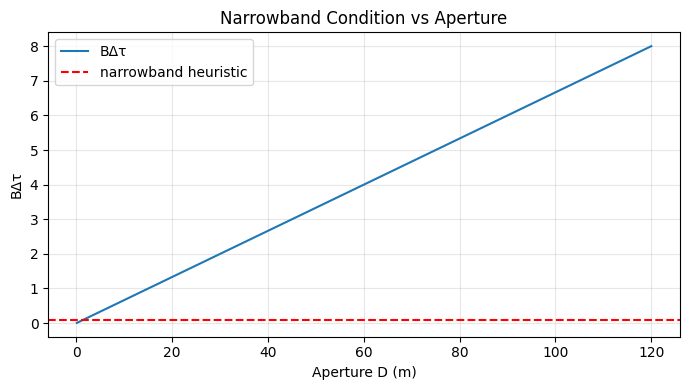

In [134]:
# Section 43: 问答记录：高载频（毫米波）+ 小带宽时，窄带近似更准还是更不准？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 追问：但高频阵列常把间距设为 $d\approx \lambda/2$，这会改变 $\Delta\tau$ 吗？

你的推理记录：

如果 $f_c$ 升高导致波长 $\lambda$ 变短，为了避免栅瓣常取 $d\approx \lambda/2$，那 $d$ 会变小，从而 $\Delta\tau$ 会变小；因此窄带近似会更准确。

解释记录：

这个推理是对的：如果你在“阵列设计”层面让阵元间距随 $\lambda$ 缩小，那么阵列的物理孔径（或至少每相邻阵元间的几何时延）会随之变小，$B\Delta\tau$ 更容易满足，从而窄带近似更稳。

> [!TIP]
> **深度思考：现实系统为什么反而可能更难？**
> 迁移到毫米波/太赫兹往往是为了获得更大的吞吐量，也就倾向于使用更大的绝对带宽 $B$。
> 即使 $\Delta\tau$ 因阵列更紧凑而变小，$B$ 的增长也可能更快，使得 $B\Delta\tau$ 反而变大，从而让窄带假设面临更大挑战。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/597688491.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


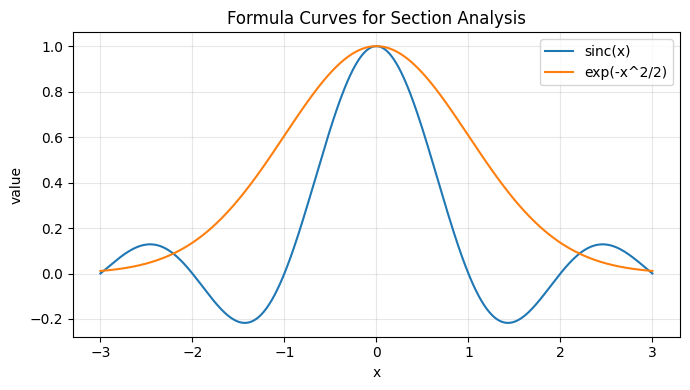

In [135]:
# Section 44: 追问：但高频阵列常把间距设为 $d\approx \lambda/2$，这会改变 $\Delta\tau$ 吗？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 打破假设：当 $B\Delta\tau$ 不再很小（宽带阵列）怎么办？

当绝对带宽 $B$ 大幅增加时，即使由于阵列更紧凑使 $\Delta\tau$ 稍微变小，乘积 $B\Delta\tau$ 仍可能跨过“远小于 1”的阈值。此时前面讨论的宽带现象（如 beam squint、fill-up/aperture filling 等）会变得不可忽视：**只做相移**不再能让全频段都“对齐”。

工程上常见的应对思路可以粗分为三类：

1. **子阵划分（Sub-arraying）**  
   把大阵列拆成多个小子阵：子阵内部仍用相移（便宜、简单），子阵之间再用更昂贵的真时延/宽带补偿做拼接。这是一种典型的性能-成本折中。

2. **真时延（True Time Delay, TTD）**  
   放弃“相移≈时延”的近似，在每路（或每个子阵）实现真正的时延补偿：硬件延时线/光纤，或数字域分数时延 FIR（TDL）。

3. **频域分解/子带处理（Wideband Synthesis / Sub-band Processing）**  
   把宽带信号分成很多窄窄的子带：每个子带内部 $B_{\text{sub}}\Delta\tau$ 更小，近似窄带成立；再对每个子带分别做相位补偿/波束形成，最后融合。

---


Approx narrowband boundary D* = 1.6 m


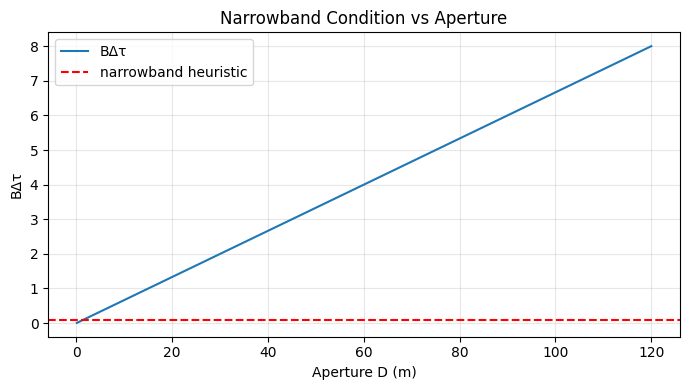

In [136]:
# Section 45: 打破假设：当 $B\Delta\tau$ 不再很小（宽带阵列）怎么办？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 问答记录：子带“切片处理” vs 时域 TTD（大 FIR），各自优劣是什么？

你的结论记录：

优势：计算复杂度降低，处理 time delay 更方便。

补充整理（更工程化的对比）：

把宽带切成很多子带做频域波束形成，常见优点是：

- **计算效率**：FFT/IFFT 的复杂度增长慢（$N\log N$），对“长滤波器/大时延”比直接时域卷积更省。
- **易于频率依赖补偿**：每个频点（或子带中心频率）可用不同权重 $w_n(f)$，天然支持频率依赖的 steering/补偿。

但它也有比较实在的代价：

1. **边缘效应与频谱泄漏**：块处理需要加窗、Overlap-Add/Overlap-Save 等，工程实现更复杂。
2. **块延迟（Latency）**：FFT 需要攒够一块数据才能处理，会引入 block delay；对强实时系统可能不可接受。
3. **频率离散导致的误差**：只在 FFT 的 bin 中心频率补偿时，能量落在 bin 之间会带来指向/补偿误差；可用更大 FFT 点数缓解，但会增加算力与延迟。
4. **流水线与带宽压力**：多通道系统下，FFT→乘权→IFFT 的流水线对内存带宽、并行调度提出更高要求。

一个简化对比表（抓住“实时性 vs 计算效率”的核心矛盾）：

| 特性 | 时域 TTD（分数时延 FIR/TDL） | 频域子带（FFT 切片） |
| --- | --- | --- |
| 实时性 | 高（流式/逐点） | 低（块处理） |
| 计算 | 乘加多（与抽头数 $L$ 成正比） | FFT 高效但有 I/O/缓存开销 |
| 精度与建模 | 直接逼近真时延，跨频段一致性更好 | 受 bin 近似、窗函数、泄漏影响 |
| 工程复杂度 | 每路滤波器多、系数管理多 | FFT 流水线复杂、内存与调度压力大 |

> [!TIP]
> **选择题**
> 如果系统要求极低延迟（例如 $1\ \mu s$ 量级以内）、阵列规模不大但必须宽带补偿，你更倾向于哪种？
>
> - 时域 TTD（分数时延 FIR/硬件真时延）
> - 频域子带（FFT 切片）

> [!NOTE]
> **参考答案**
> 更倾向于时域 TTD：块处理的 FFT 延迟往往是硬伤，而 TTD 更容易做到确定性的低延迟。

---


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/264337399.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


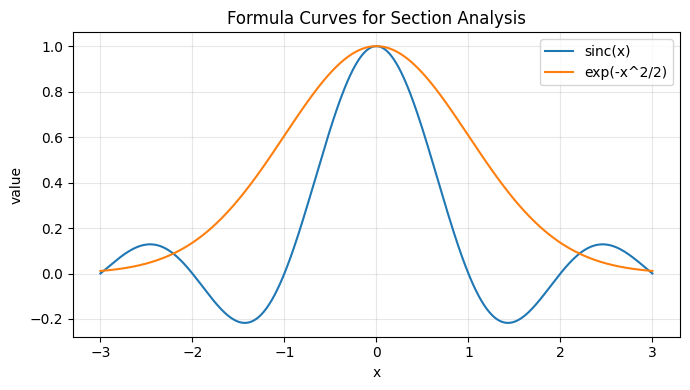

In [137]:
# Section 46: 问答记录：子带“切片处理” vs 时域 TTD（大 FIR），各自优劣是什么？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 分数时延 FIR（Fractional Delay）：一串抽头是怎么“实现延迟”的？

在离散时间里，整数采样延迟很简单：延迟 $D$ 个采样点就是 $x[k-D]$。但真实世界的传播时延 $\tau$ 往往不是采样周期 $T_s$ 的整数倍，需要实现 **分数延迟**：

$$
D=\frac{\tau}{T_s}\notin\mathbb{Z}
$$

这时我们需要用 FIR 滤波器去近似理想分数延迟系统的频响：

$$
H_{\text{ideal}}(e^{j\omega}) = e^{-j\omega D}
$$

直觉上：滤波器系数在做“插值”，让信号能在采样点之间被平滑地“挪动”一小段时间。

> [!TIP]
> **下一步（你想从哪个角度理解分数延时？）**
> 1. **插值视角**：如何在两个采样点之间“造”出值（Lagrange/Farrow 等）。  
> 2. **频响视角**：如何让 $H(e^{j\omega})$ 逼近 $e^{-j\omega D}$（相位线性、幅度尽量平坦）。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/721752046.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


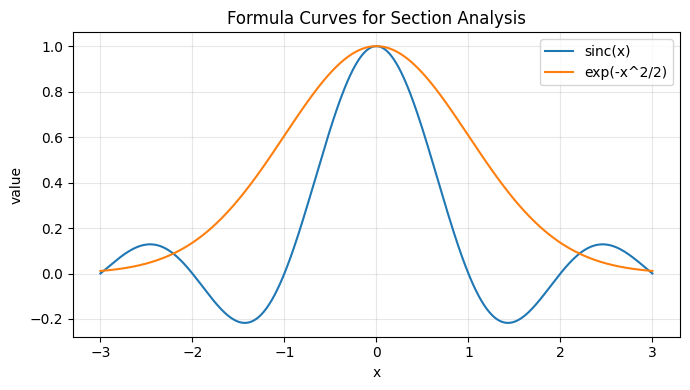

In [138]:
# Section 47: 分数时延 FIR（Fractional Delay）：一串抽头是怎么“实现延迟”的？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 分数延时（插值视角）：用有限抽头逼近理想 sinc

采样定理告诉我们：如果基带信号带限且采样率足够高，那么离散采样点“原则上”包含了连续时间信号的全部信息。实现分数延迟的本质，就是用已有采样点**插值**出“采样点之间”的值。


Δφ range: -3.141592653589793 to 3.141592653589793


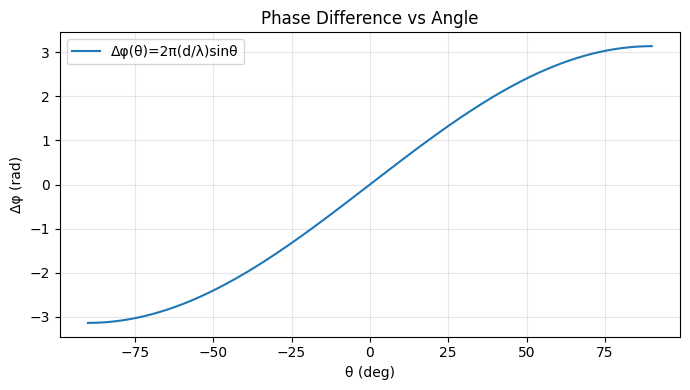

In [139]:
# Section 48: 分数延时（插值视角）：用有限抽头逼近理想 sinc
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 1) 理想分数延迟：sinc 插值的视角

如果我们把离散信号 $x[k]$ 看作某个带限连续信号 $x(t)$ 在 $t=kT_s$ 处的采样，那么理想重建使用 sinc 插值核：

$$
x(t)=\sum_{k=-\infty}^{\infty} x[k]\;\mathrm{sinc}\!\Big(\frac{t-kT_s}{T_s}\Big)
$$

要实现延迟 $\tau = DT_s$（其中 $D$ 可以是非整数），理想情况下就是取：

$$
y[m]=x\big((m-D)T_s\big)
$$

把它写成离散卷积，会得到一组“无限长”的滤波器系数，形状类似偏移后的 sinc：

$$
h_D[k]=\mathrm{sinc}(k-D),\qquad y[m]=\sum_{k=-\infty}^{\infty} h_D[k]\;x[m-k]
$$


Δφ range: -3.141592653589793 to 3.141592653589793


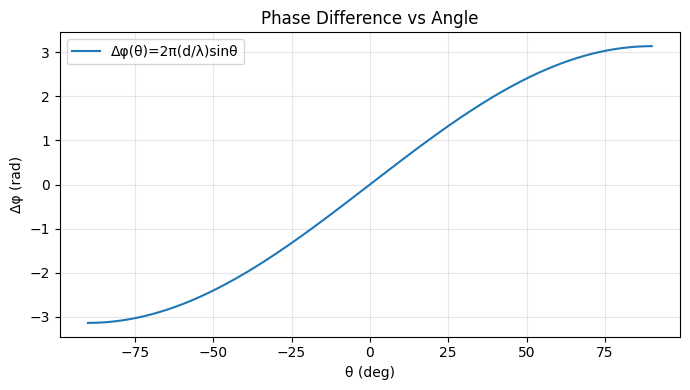

In [140]:
# Section 49: 1) 理想分数延迟：sinc 插值的视角
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 2) 从理想到工程：为什么要用有限抽头 FIR？

理想 $h_D[k]$ 是无限长的，硬件/实时系统做不到，于是工程上用有限抽头（长度 $L$）去截断/逼近：

$$
y[m]\approx \sum_{k=0}^{L-1} h_D[k]\;x[m-k]
$$

这就是“TDL/分数延时 FIR”的核心：用多个邻近采样点做**加权平均**来“合成”一个位于采样点之间的值。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1099188632.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


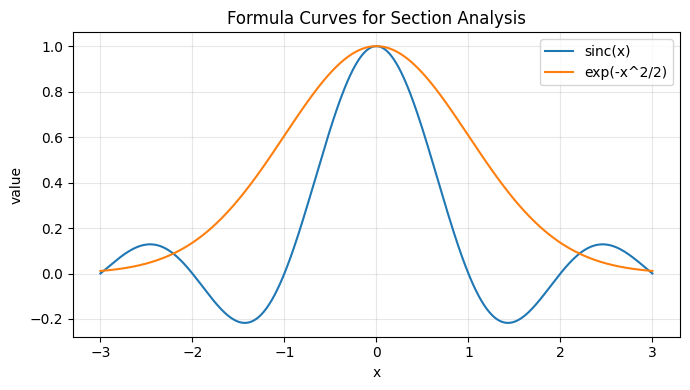

In [141]:
# Section 50: 2) 从理想到工程：为什么要用有限抽头 FIR？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 3) 抽头数（taps）越多越好吗？

从纯信号处理角度看：在相同设计方法下，抽头数增加通常意味着更好的逼近能力（频带内幅度更平坦、相位更接近理想线性），因此**误差一般会变小**。

但工程上要在“精度 vs 代价”之间拔河：

- 抽头越多：每路每采样需要更多乘加（算力/功耗上升），同时带来更长的群时延（总体延迟增加）。
- 抽头越少：实现更轻量，但宽带内幅度/相位误差更大，延迟不再“对所有频率都一致”。

> [!TIP]
> **经验性结论**
> 抽头“越多越好”在数学上成立，但工程上追求的是“刚刚好”：满足指标的最小 $L$。

---


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2759356582.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


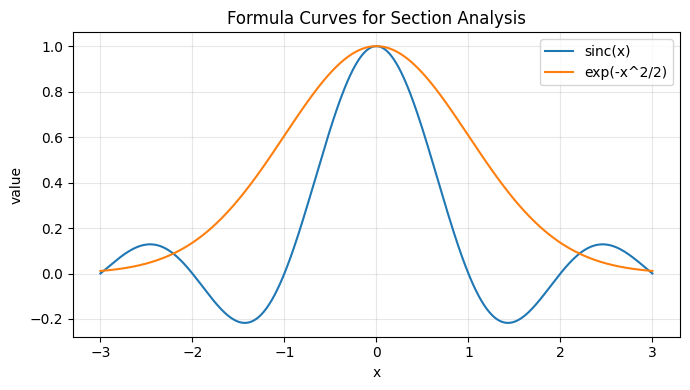

In [142]:
# Section 51: 3) 抽头数（taps）越多越好吗？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 问答记录：为什么窄带时甚至“一个复乘”就够了？

你的直觉记录：

既然分数延时是插值，那抽头是不是越多越好？如果信号满足窄带条件，是不是就不需要那么多抽头，甚至 1 个点加相位旋转就够？

解释记录：

是的，这正好把“窄带假设”和“分数延时插值”统一起来：

- 宽带信号变化快，要想让**全频段**的时延都一致，就必须更像理想 $e^{-j\omega D}$，因此需要更强的滤波器逼近能力（更多抽头，或更复杂结构）。
- 窄带信号满足 $B\Delta\tau\ll 1$ 时，包络在孔径时延范围内几乎不变，延迟的主要效果体现在载波相位。此时用

$$
e^{-j2\pi f_c\tau}
$$

做相位旋转，已经能在关心的窄频段内近似“延迟”，等价于把分数延时 FIR 的复杂度压缩到极致。

---


Approx narrowband boundary D* = 1.6 m


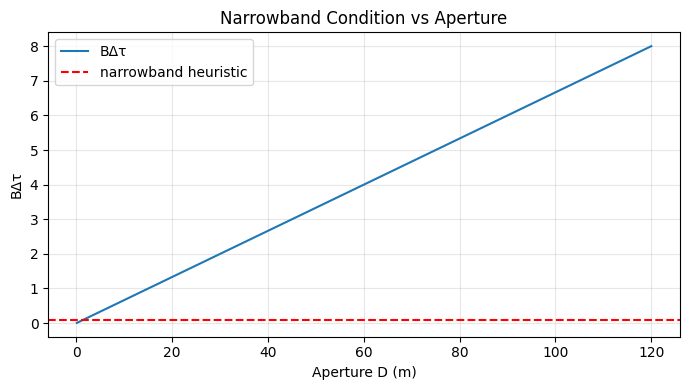

In [143]:
# Section 52: 问答记录：为什么窄带时甚至“一个复乘”就够了？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 问答记录：不改算法，想“强行回到窄带”，硬件上能怎么做？

你的选择记录：

如果出现明显宽带效应，但不想做 TTD（大 FIR）也不想做 FFT 子带切片，想通过硬件设计让系统回到“窄带”，应该缩小阵列物理尺寸（减小 $\Delta\tau$）。

解释记录：

这个选择是正确的：窄带判据的核心是 $B\Delta\tau$。如果你不想动算法、也不想牺牲带宽 $B$，那最直接的办法就是降低 $\Delta\tau$，例如缩小阵列孔径 $D$ 或使用子阵（Sub-arraying）来限制每次参与窄带处理的有效孔径。

顺便澄清另外两个选项的“作用边界”：

- **增加带宽 $B$**：会让 $B\Delta\tau$ 变大，通常只会让窄带假设更难成立。
- **提高采样频率**：不会改变物理传播时延 $\Delta\tau$，因此不会从根本上改变 $B\Delta\tau$ 是否很小；但它能让数字分数延时的“可实现性/精度”变好（更细的时间栅格、更容易插值），属于“实现层面”的帮助，而不是“模型判据”的改变。

---


Approx narrowband boundary D* = 1.6 m


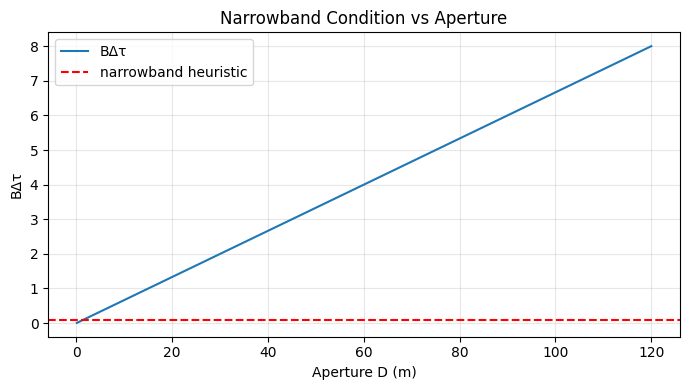

In [144]:
# Section 53: 问答记录：不改算法，想“强行回到窄带”，硬件上能怎么做？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# MUSIC：窄带子空间“超分辨率”测向

在窄带假设成立时，MUSIC（Multiple Signal Classification）是一类非常经典、也非常优雅的 DoA（Direction of Arrival）估计算法。它的核心思想可以浓缩成一句话：

> **真实方向的 steering vector 与噪声子空间正交**，所以在该方向上构造的“正交性度量”会出现尖峰。

下面用“拆步骤 + 引导问题”的方式把它讲清楚。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/199211525.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/199211525.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/199211525.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/199211525.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/199211525.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj().T) 

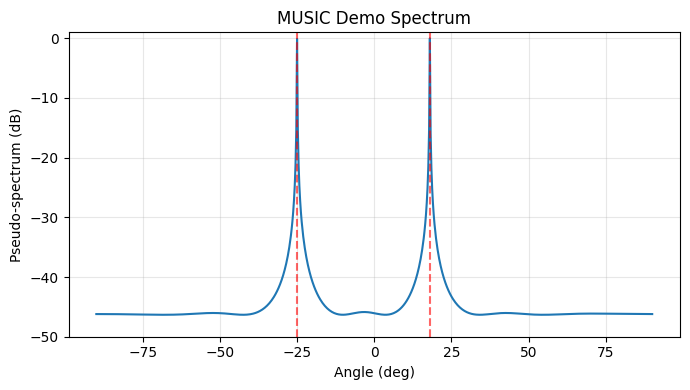

In [145]:
# Section 54: MUSIC：窄带子空间“超分辨率”测向
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 1) 信号子空间与噪声子空间：先把数据“分家”

沿用窄带阵列模型（单快拍）：

$$
\mathbf{x}[k]=\mathbf{A}\mathbf{s}[k]+\mathbf{n}[k],\qquad \mathbf{x}[k]\in\mathbb{C}^{N\times 1}
$$

用 $K$ 个快拍形成样本协方差：

$$
\hat{\mathbf{R}}=\frac{1}{K}\sum_{k=1}^{K}\mathbf{x}[k]\mathbf{x}[k]^{H}
$$

然后对 $\hat{\mathbf{R}}$ 做特征值分解（EVD）：

$$
\hat{\mathbf{R}}=\mathbf{U}\mathbf{\Lambda}\mathbf{U}^H
$$

在常见假设下（噪声空间白、与信号不相关），当空间中有 $p$ 个窄带信号源时：

- 最大的 $p$ 个特征值/特征向量张成 **信号子空间**
- 剩下的 $N-p$ 个特征值/特征向量张成 **噪声子空间**（记作 $\mathbf{U}_n$）

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1038619269.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1038619269.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1038619269.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1038619269.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1038619269.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj(

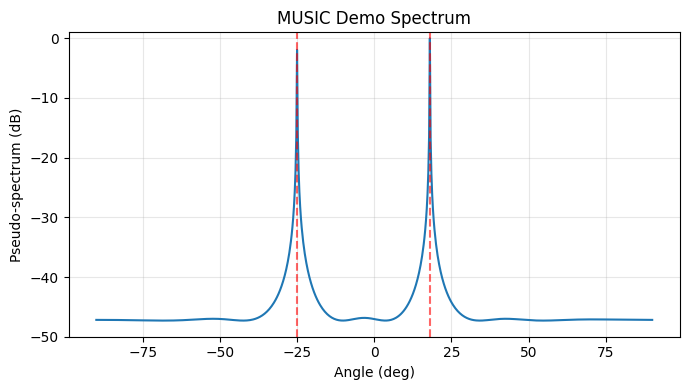

In [146]:
# Section 55: 1) 信号子空间与噪声子空间：先把数据“分家”
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2) “垂直”的奥秘：为什么 steering vector 会与噪声子空间正交？

直觉上：$\hat{\mathbf{R}}$ 的“主要能量方向”由信号贡献，而噪声子空间是“除了信号之外的其余方向”。在理想情形下，真实方向对应的 steering vector $\mathbf{a}(\theta_i)$ 落在信号子空间里，因此与噪声子空间正交：

$$
\mathbf{U}_n^H\mathbf{a}(\theta_i)\approx \mathbf{0}
$$

这就是 MUSIC 能产生“尖峰”的原因。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1402030166.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1402030166.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1402030166.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1402030166.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1402030166.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj(

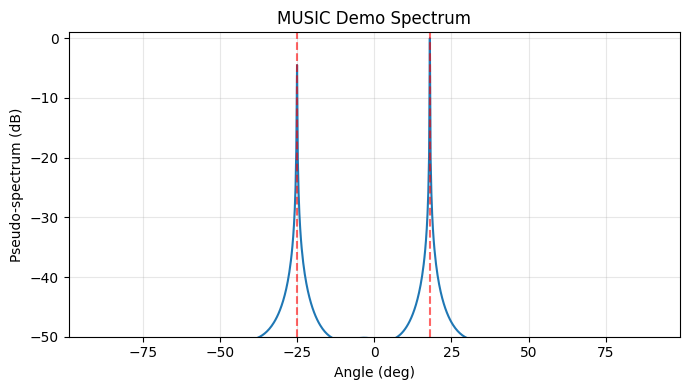

In [147]:
# Section 56: 2) “垂直”的奥秘：为什么 steering vector 会与噪声子空间正交？
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3) 寻找“无限大”：MUSIC 伪谱

MUSIC 常用的伪谱写法是：

$$
P_{\text{MUSIC}}(\theta)=\frac{1}{\mathbf{a}(\theta)^H\mathbf{U}_n\mathbf{U}_n^H\mathbf{a}(\theta)}
$$

当 $\theta$ 扫到真实方向附近时，$\mathbf{U}_n^H\mathbf{a}(\theta)$ 很小，分母很小，于是 $P_{\text{MUSIC}}(\theta)$ 出现尖峰；峰值位置就是 DoA 估计。

> [!NOTE]
> **实际实现里会遇到的两个“非理想”**
> 1. 有限快拍 $K$ 会让子空间估计有误差，所以“正交”变成“近似正交”。  
> 2. 真实噪声不一定严格白；阵列互耦、校准误差也会破坏模型。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/782790401.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/782790401.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/782790401.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/782790401.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/782790401.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj().T) 

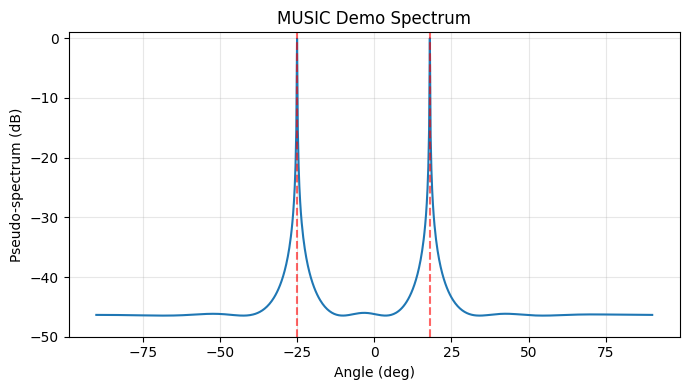

In [148]:
# Section 57: 3) 寻找“无限大”：MUSIC 伪谱
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 引导练习：8 元阵列 + 1 个窄带信号时，特征值会长什么样？

设 $N=8$，空间中只有 $p=1$ 个窄带信号源（其余为噪声）。对样本协方差 $\hat{\mathbf{R}}$ 做 EVD 得到 8 个特征值：

1. 你觉得这 8 个特征值会一样大吗？  
2. 还是会出现“1 个特别大，其余 7 个比较小（代表噪声）”？

> [!NOTE]
> **参考答案（直觉版本）**
> 更倾向于第 2 种：理想情况下会出现 **1 个明显较大** 的特征值（信号 + 噪声），以及 **7 个接近噪声方差 $\sigma^2$** 的特征值（噪声子空间）。

> [!TIP]
> **更精确的一句话**
> 若噪声是空间白噪声，则理论协方差会呈现“$p$ 个大特征值 + $N-p$ 个接近 $\sigma^2$ 的小特征值”的结构；但在有限 $K$ 时，小特征值不会完全相等，会有一定起伏。

---


Approx narrowband boundary D* = 1.6 m


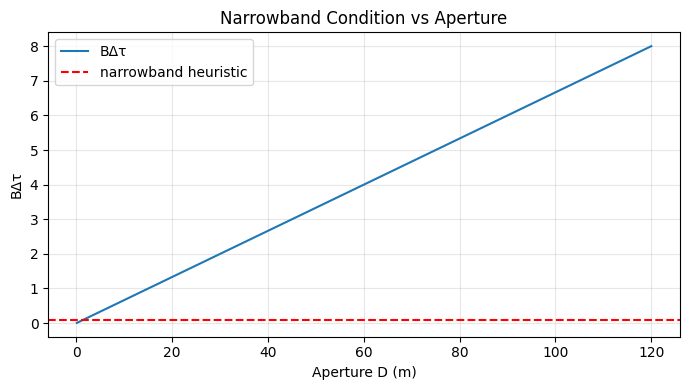

In [149]:
# Section 58: 引导练习：8 元阵列 + 1 个窄带信号时，特征值会长什么样？
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 引导练习续：把 $\mathbf{a}(\theta)$ 投影到噪声子空间，会发生什么？

已知真实方向为 $\theta_0$，其 steering vector 为 $\mathbf{a}(\theta_0)$。如果噪声子空间矩阵是 $\mathbf{U}_n$，那么在理想情况下：

$$
\mathbf{U}_n^H\mathbf{a}(\theta_0)=\mathbf{0}
$$

也就是说，真实方向的 steering vector 在噪声子空间上的投影为 0（或接近 0）。这正是 MUSIC 伪谱分母会“趋近于 0”的原因。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1056193279.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1056193279.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1056193279.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1056193279.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1056193279.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj(

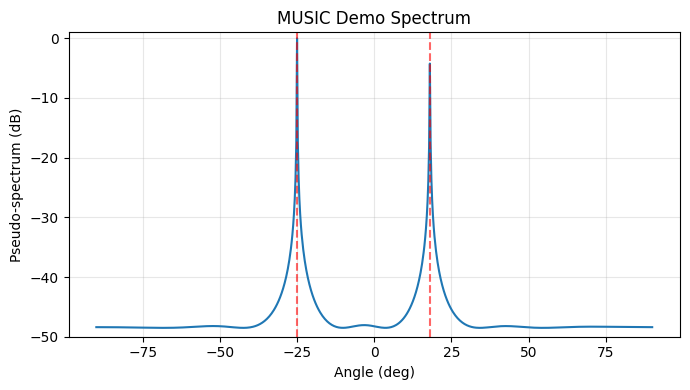

In [150]:
# Section 59: 引导练习续：把 $\mathbf{a}(\theta)$ 投影到噪声子空间，会发生什么？
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 宽带时用“中心频率 steering vector”跑 MUSIC，会发生什么？

如果信号是宽带的，但我们仍然只用中心频率 $f_c$ 构造 $\mathbf{a}(\theta)$ 并直接套用窄带 MUSIC，那么常见现象是：

- 峰值 **变矮、变圆钝**（分辨率下降）
- 峰值位置可能 **轻微偏移**（频率依赖的指向误差）


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2488289079.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2488289079.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2488289079.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2488289079.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2488289079.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj(

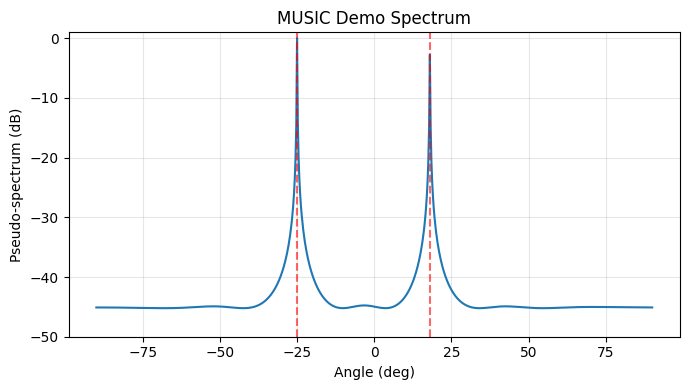

In [151]:
# Section 60: 宽带时用“中心频率 steering vector”跑 MUSIC，会发生什么？
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 为什么不是“裂成很多小山峰”？

直觉上你会觉得：不同频率分量各自“想要”的峰值位置不同，那是不是会出现很多峰？在很多情况下，结果更像是“一个土丘”而不是“很多小山”，原因通常有三点：

1. **同一个物理源**  
   宽带信号虽然包含很多频率，但它们来自同一个方向/同一个源。MUSIC 的“峰的个数”更多反映的是“源的个数 $p$”，而不是“频率分量的个数”。

2. **频率导致的指向变化通常是连续且相近的**  
   对同一方向，频带内不同 $f$ 的“最佳对齐方向”往往在角度轴上是连续偏移的一段小范围，而不是相互隔很远的多个不相关方向。把一堆“很近的尖峰”叠加，视觉上更像一个变宽的峰/土丘。

3. **协方差的平均效应会稀释尖锐的正交性**  
   MUSIC 依赖“几乎完美的正交”。宽带下不同频率的相位关系混在一起会让信号子空间不再那么“纯”，导致 $\mathbf{U}_n^H\mathbf{a}(\theta)$ 不会在某个单点上特别接近 0，于是尖峰被抹平。

> [!NOTE]
> **什么时候可能真的出现多个局部峰？**
> 当频带极宽、阵列孔径大、且你用的窄带 steering vector 失配很严重时，伪谱可能出现多个局部极值（甚至假峰）。但“更常见/更稳定”的退化表现仍是峰变宽、变矮、偏移。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1491835234.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


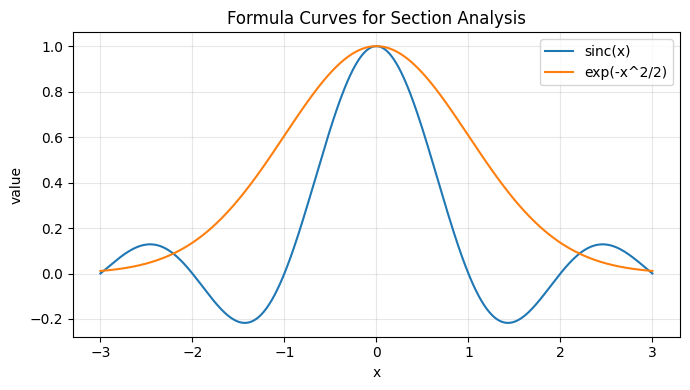

In [152]:
# Section 61: 为什么不是“裂成很多小山峰”？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 宽带 MUSIC 的常见补救：ISSM（不相干子空间方法）

一个经典思路是把宽带切成多个窄带子带（或 FFT bin），在每个子带分别做窄带 MUSIC，再把结果融合。这类方法常被称为 ISSM（Incoherent Signal Subspace Method）。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1408005663.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1408005663.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1408005663.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1408005663.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1408005663.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj(

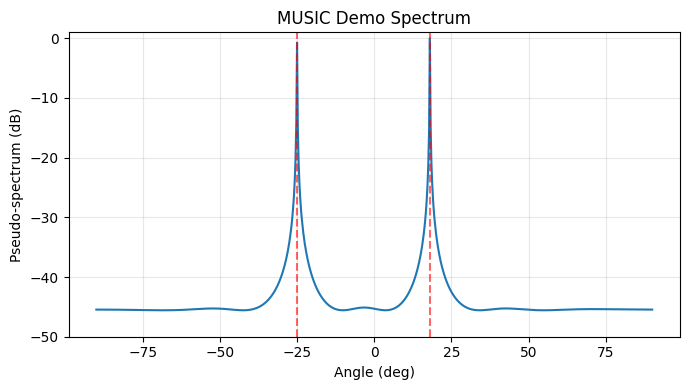

In [153]:
# Section 62: 宽带 MUSIC 的常见补救：ISSM（不相干子空间方法）
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 1) “结果层”的简单相加

对每个子带中心频率 $f_\ell$ 计算伪谱 $P_\ell(\theta)$，然后做加权求和：

$$
P_{\text{ISSM}}(\theta)=\sum_{\ell=1}^{L} \alpha_\ell\, P_\ell(\theta)
$$

其中 $\alpha_\ell$ 可用于忽略低 SNR 子带或做能量加权。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1654188063.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


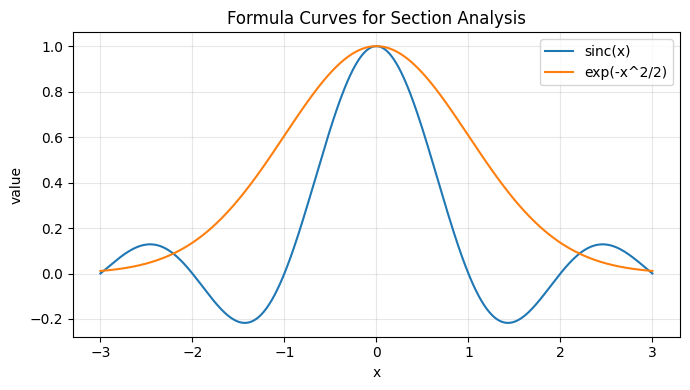

In [154]:
# Section 63: 1) “结果层”的简单相加
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 2) “子空间层”的对齐融合（聚焦/相干方法）

更进阶的方法不是加伪谱，而是把不同频率下的子空间先“对齐”到参考频率，再融合出一个更一致的协方差/子空间（常被统称为 focusing / coherent subspace methods）。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/119515884.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/119515884.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/119515884.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/119515884.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/119515884.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj().T) 

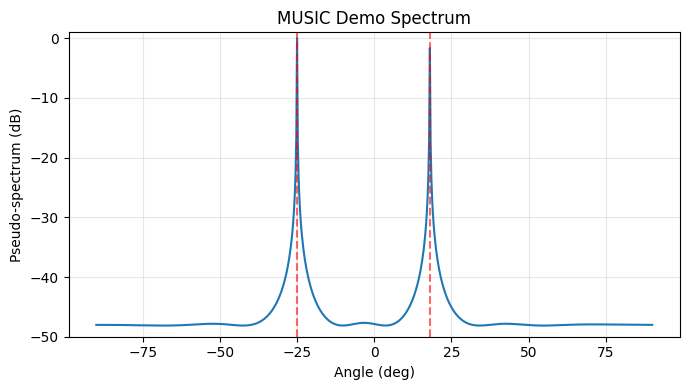

In [155]:
# Section 64: 2) “子空间层”的对齐融合（聚焦/相干方法）
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### 问答记录：为什么 ISSM 叫“不相干”？它会丢掉什么？

你的困惑记录：

对于极短的宽带脉冲，不同频率成分之间有很强的相位耦合。如果把它拆成子带分别处理再加起来，会丢掉“时域波形（相位一致性）”，但这里不太懂。

解释记录（把“相位一致性”翻译成数学）：

一个脉冲在时域很“尖”，本质上依赖于频域各频率分量在某个时刻 **相位对齐**。可以把连续时间信号写成：

$$
x(t)=\int |X(f)|\,e^{j\phi(f)}\,e^{j2\pi f t}\,df
$$

- $|X(f)|$ 决定“每个频率有多少能量”
- $\phi(f)$ 决定“这些频率在时域怎么叠加”（在哪个时刻同相相加、在哪些时刻相互抵消）

**不相干（incoherent）融合**的典型特点是：更关注每个子带的“能量/谱形”，而不显式保留并对齐跨子带的相位关系。这样做对很多“稳态窄带/长时持续”信号足够，但对“极短脉冲”会带来一个直观后果：

- 如果跨频段的相位没有被一致地对齐，原本应该在某个 $t_0$ 同相叠加的频率分量，会在时域里“错开”叠加  
  $\Rightarrow$ 脉冲峰值变矮、主瓣变宽、旁瓣结构改变（看起来像“散架”）

> [!TIP]
> **一句话理解**
> 脉冲的“尖”来自全频段的相干叠加；只做不相干的子带结果相加，相当于丢掉了让它“尖起来”的那份跨频段相位一致性信息。

---


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1426440593.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


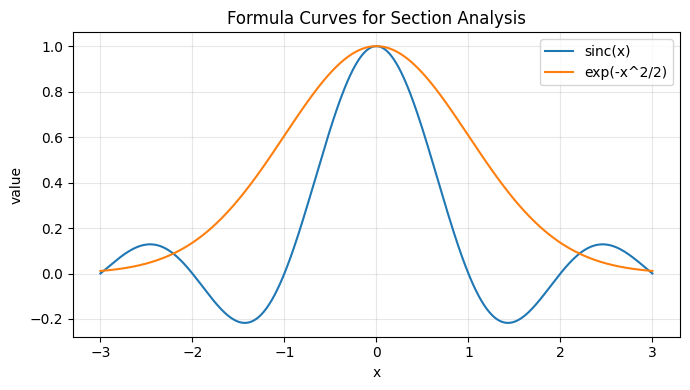

In [156]:
# Section 65: 问答记录：为什么 ISSM 叫“不相干”？它会丢掉什么？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 时域直觉：为什么“相位不对齐”会让脉冲变矮、变宽？

从时域来看，脉冲的“形”是由许多不同频率分量在某个时刻**精准对齐**后叠加出来的。可以把每个频率分量想象成一名短跑运动员：

- **理想状态**：所有人同时冲线（相位一致），在示波器上形成能量高度集中的尖峰。
- **被拆散的状态**：不同频率分量由于补偿不一致而“早到/晚到”（相位超前/滞后），叠加能量在时间轴上摊开。

于是会出现两个典型变化：

1. **峰值变矮**：原本同相叠加的能量被分散到不同时间点。
2. **波形变宽**：主能量不再集中，可能出现拖尾/鼓包。

这类现象常被笼统地称为**色散（dispersion）**或**群时延畸变**：不同频率分量“等效延迟不同”，导致时域波形被拉伸。

---


Δφ range: -3.141592653589793 to 3.141592653589793


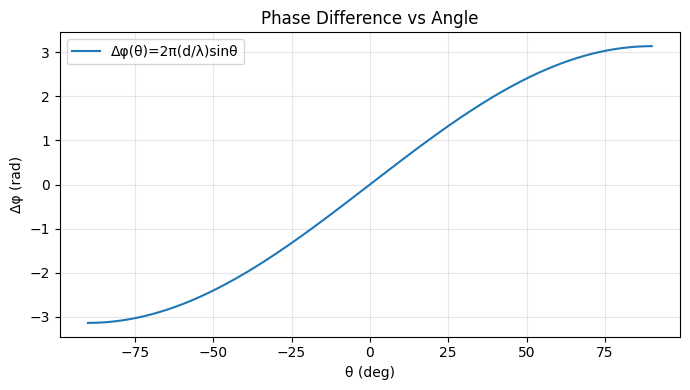

In [157]:
# Section 66: 时域直觉：为什么“相位不对齐”会让脉冲变矮、变宽？
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## CSS（相干子空间）与聚焦矩阵：把“彩虹”重新聚成“白光”

ISSM 之所以叫不相干，是因为它倾向于在“结果层”融合（加伪谱/加能量），而不显式保留并对齐跨频段的相位关系。若希望恢复跨频段的相干性，一个典型方向是 CSS（Coherent Signal Subspace）/ focusing 类方法。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/268572208.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/268572208.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/268572208.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/268572208.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/268572208.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj().T) 

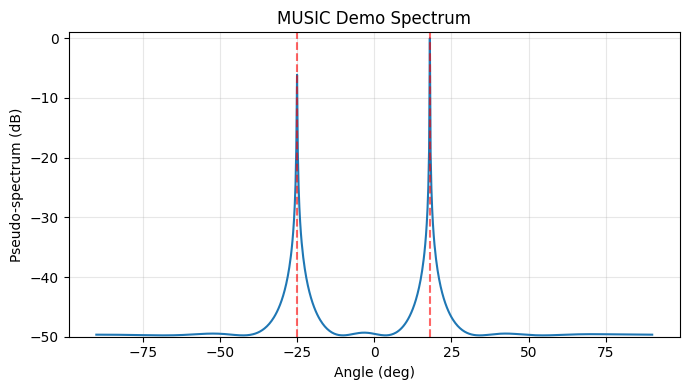

In [158]:
# Section 67: CSS（相干子空间）与聚焦矩阵：把“彩虹”重新聚成“白光”
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 1) 核心目标：让不同频率的阵列流形“看起来像同一个频率”

不同频率下 steering vector 依赖于 $f$。CSS 希望构造一个聚焦矩阵 $\mathbf{T}(f)$，把频率 $f$ 下的阵列响应映射到参考频率 $f_0$ 的“坐标系”里：

$$
\mathbf{T}(f)\,\mathbf{a}(\theta,f)\ \approx\ \mathbf{a}(\theta,f_0)
$$

做完这个变换后，就可以把多个频段的“对齐后数据/协方差”融合起来，再用类似窄带 MUSIC 的流程做子空间分解与峰值搜索。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2427445769.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


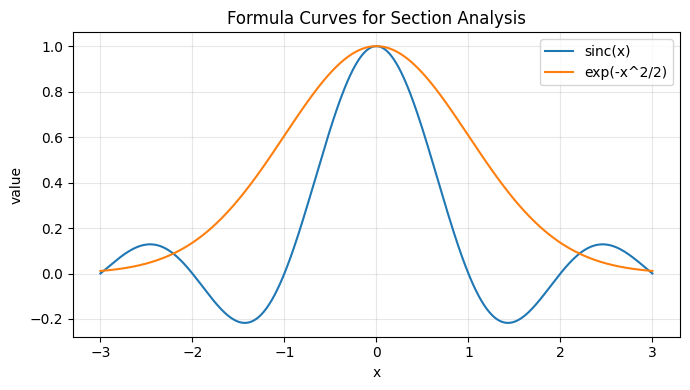

In [159]:
# Section 68: 1) 核心目标：让不同频率的阵列流形“看起来像同一个频率”
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 2) “鸡生蛋”问题：聚焦矩阵常需要初始方向

很多构造 $\mathbf{T}(f)$ 的方式依赖“你大概知道信号在哪个方向/扇区”。工程上常见的起步方式是：

- 先用稳健但分辨率低的算法（例如常规波束形成 CBF）做一次粗扫，得到粗略 $\hat{\theta}$；
- 再围绕该扇区做 CSS 聚焦 + MUSIC 精估；
- 必要时迭代更新 $\hat{\theta}$（粗→细→更细）。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/339972638.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


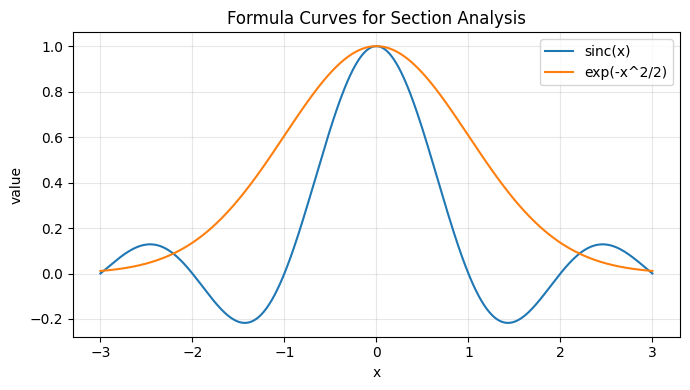

In [160]:
# Section 69: 2) “鸡生蛋”问题：聚焦矩阵常需要初始方向
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 3) 多源宽带时的软肋：多信号 + 单预设方向会产生聚焦误差

当存在多个相近信号源时，如果只用一个预设方向 $\theta_{\text{ref}}$ 来构造聚焦矩阵，往往会出现：

- 峰变宽（能量未能同时对齐）
- 分辨率下降（两个源更容易糊在一起）
- 估计偏置（结果向 $\theta_{\text{ref}}$ 偏）

---


Approx narrowband boundary D* = 1.6 m


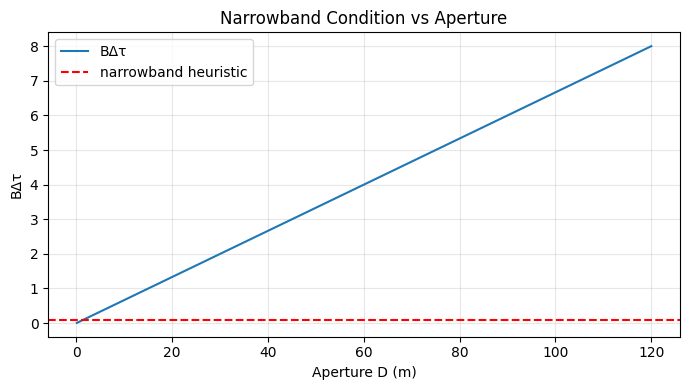

In [161]:
# Section 70: 3) 多源宽带时的软肋：多信号 + 单预设方向会产生聚焦误差
c = 3e8
B = 20e6
D = np.linspace(0.1, 120, 400)
delta_tau = D / c
metric = B * delta_tau
threshold = 0.1
cross_idx = np.argmax(metric > threshold)
if metric[cross_idx] > threshold:
    print('Approx narrowband boundary D* =', round(D[cross_idx], 2), 'm')
plt.figure(figsize=(7, 4))
plt.plot(D, metric, label='BΔτ')
plt.axhline(threshold, color='r', ls='--', label='narrowband heuristic')
plt.xlabel('Aperture D (m)')
plt.ylabel('BΔτ')
plt.title('Narrowband Condition vs Aperture')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 工程折中：多点/分扇区聚焦与“先粗后细”

为缓解“单预设方向”的问题，一个务实的策略是**分扇区/多点聚焦**：

1. 把扫描角域切成若干扇区；
2. 每个扇区选一个参考方向，构造对应的聚焦矩阵；
3. 在该扇区内运行窄带算法（例如 MUSIC）；
4. 拼接/融合各扇区结果。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3818682372.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


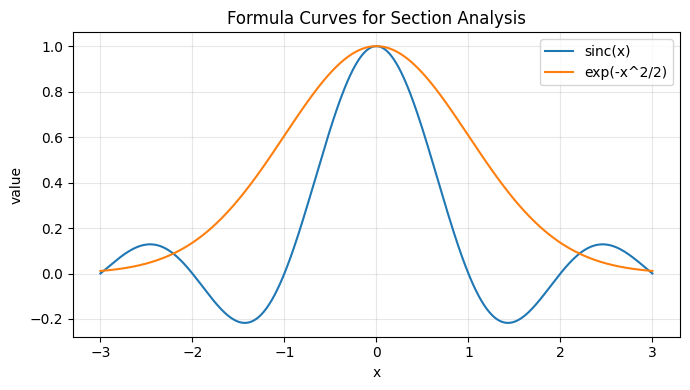

In [162]:
# Section 71: 工程折中：多点/分扇区聚焦与“先粗后细”
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 动态聚焦：只对“有信号的扇区”做高精度

如果算力有限，可以先用低成本方法判定信号落在哪个扇区，再只对该扇区做 CSS（类似“搜索-跟踪”模式），以节省计算资源。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3925247044.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


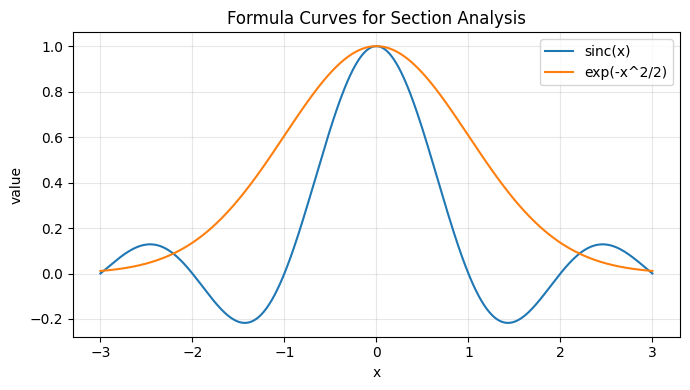

In [163]:
# Section 72: 动态聚焦：只对“有信号的扇区”做高精度
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 多信号跨扇区：算力只够 1 套聚焦矩阵时怎么办？

一种常见调度是**分时复用**：按时间轮询不同扇区（牺牲刷新率换覆盖度）。另一种是“折中聚焦”（一次覆盖更宽角域但分辨率下降）。

> [!TIP]
> **直觉结论（高动态场景）**
> 在高速动态任务里，“折中聚焦”常以分辨率/偏置为代价；“分时复用”以刷新率为代价。哪种更危险取决于任务：如果必须区分相近目标并给出精确角度，分辨率损失往往更致命；如果目标快速穿越扇区，刷新率不足也会带来漏检风险。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1013758078.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


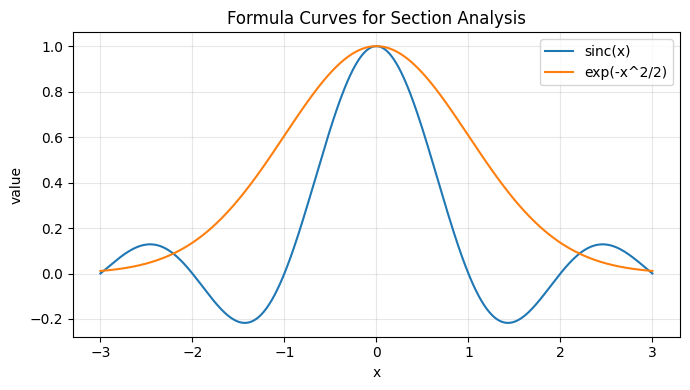

In [164]:
# Section 73: 多信号跨扇区：算力只够 1 套聚焦矩阵时怎么办？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Q：关于 Uli 文章 4.1 Experiment Setup 部分的疑问

> 原文摘录（你贴的这一段）：
>
> “遵循由 $\theta_{i+1}=\theta_i+[3,-3,2]\odot\sin(\omega_0\cdot t)+w_i$ 给出的演化模型（2），其中 $\omega_0=[-0.15,0.25,0.15]$，$w_i$ 是标准偏差为 0.03 的 i.i.d. 高斯噪声。在随机选择的块中引入分布偏移，以模拟部署中遇到的校准漂移。这些偏移模拟了两种类型的阵列缺陷：（i）距离失调，表示与标称半波长间距的偏差，被建模为均匀扰动 $\delta_n\sim U(-\eta,\eta)$，$\eta\in\{0.3,0.9,1.2\}$，影响相位响应；以及（ii）几何噪声，表示额外的转向矢量扰动，建模为方差为 0.9 的加性复高斯噪声 $\epsilon_{n,\theta}$。综合效应产生了一个受扰的转向矩阵：…”


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/858869044.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


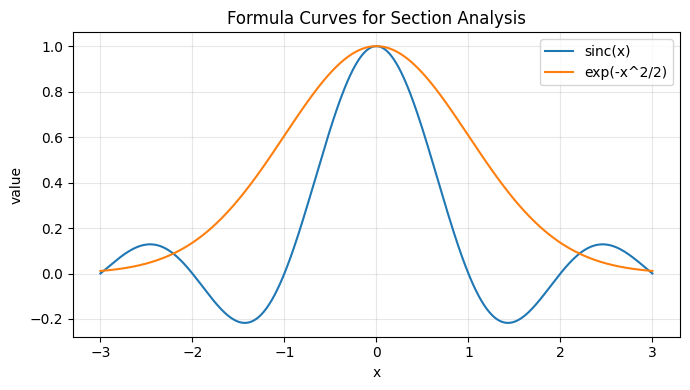

In [165]:
# Section 74: Q：关于 Uli 文章 4.1 Experiment Setup 部分的疑问
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Q1：什么叫 source 在 100 个 blocks 上移动？

核心对齐点：**block 是时间段**；source 的 “move” 指 **block 与 block 之间 DoA 更新**，而不是在单个 block 内连续变化。

- 第 $i$ 个 block：收集 $T$ 个 snapshots（例如 $T=200$ 或 $T=20$）
- 同一个 block 内：通常假设 DoA 近似不变（便于构造 $X_i\in\mathbb{C}^{N\times T}$）
- 从 block $i\to i+1$：更新一次 DoA，表示源“移动一小步”

因此，“source 在 100 个 blocks 上移动” 可以理解为：

- 他们仿真了 **100 个连续时间片段（100 个 block）**；
- 在每个 block 的边界处更新一次 $\theta_i$，得到长度为 100 的 DoA 轨迹（共更新 99 次）。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1383180096.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


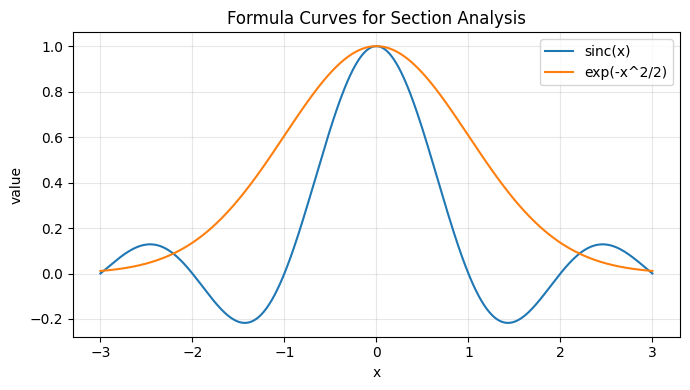

In [166]:
# Section 75: Q1：什么叫 source 在 100 个 blocks 上移动？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Q2：DoA 是怎么“移动”的？（演化模型）

论文给的演化式：

$$
\theta_{i+1}=\theta_i + [3,-3,2]\odot \sin(\omega_0\cdot t) + w_i,\quad
\omega_0=[-0.15,0.25,0.15],\quad w_i\sim\mathcal{N}(0,0.03^2).
$$

逐项理解：

- $\theta_i$：第 $i$ 个 block 的真实 DoA（这里是 3 个源，所以是 3 维）
- $[3,-3,2]$：每个源角度摆动幅度（单位在实现里可能做过归一化；但直觉上就是“摆动幅度”）
- $\omega_0$：每个源的“摆动频率/节奏”
- $\odot$：逐元素乘法，让每个源使用自己的幅度与频率
- $w_i$：过程噪声，让轨迹不是完全光滑的正弦而带有随机抖动


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3243820527.py:7: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3243820527.py:7: RuntimeWarning: overflow encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3243820527.py:7: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3243820527.py:8: RuntimeWarning: divide by zero encountered in matmul
  R = (X @ X.conj().T) / snapshots
/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/3243820527.py:8: RuntimeWarning: overflow encountered in matmul
  R = (X @ X.conj(

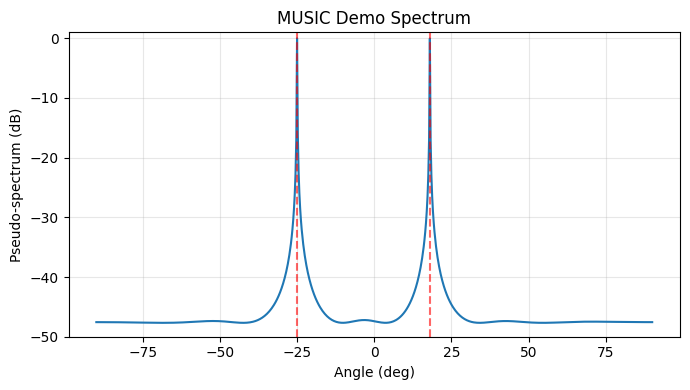

In [167]:
# Section 76: Q2：DoA 是怎么“移动”的？（演化模型）
m, snapshots = 8, 600
true_angles = np.array([-25, 18])
sensor = np.arange(m)[:, None]
A = np.exp(-1j * np.pi * sensor * np.sin(np.deg2rad(true_angles))[None, :])
S = (np.random.randn(2, snapshots) + 1j*np.random.randn(2, snapshots)) / np.sqrt(2)
X = A @ S + 0.15*(np.random.randn(m, snapshots)+1j*np.random.randn(m, snapshots))/np.sqrt(2)
R = (X @ X.conj().T) / snapshots
w, v = eigh(R)
En = v[:, :m-2]
scan = np.linspace(-90, 90, 721)
P = []
for ang in scan:
    a = np.exp(-1j*np.pi*np.arange(m)*np.sin(np.deg2rad(ang)))[:, None]
    denom = np.real((a.conj().T @ En @ En.conj().T @ a).squeeze())
    P.append(1.0 / max(denom, 1e-12))
P = np.array(P)
P_db = 10*np.log10(P / P.max())
plt.figure(figsize=(7, 4))
plt.plot(scan, P_db, lw=1.5)
for ta in true_angles:
    plt.axvline(ta, color='r', ls='--', alpha=0.6)
plt.ylim(-50, 1)
plt.xlabel('Angle (deg)')
plt.ylabel('Pseudo-spectrum (dB)')
plt.title('MUSIC Demo Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Q3：校准漂移（calibration drift）到底在“漂移”什么？

一句话：**不是只有 $\theta_i$ 在变；他们还在某些随机 block 开始让“阵列响应”变了**，也就是 steering vector / steering matrix 发生变化，从而造成 **distribution shift（输入分布漂移）**。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1139161345.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


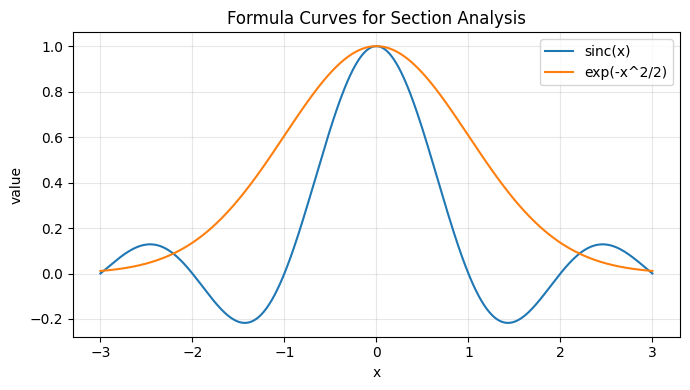

In [168]:
# Section 77: Q3：校准漂移（calibration drift）到底在“漂移”什么？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### A) 理想阵列：steering vector 是“角度 → 相位模式”的映射

对理想 ULA（窄带、远场平面波），第 $n$ 个阵元的导向向量元素常写为：

$$
[a(\theta)]_n = e^{-j\frac{2\pi}{\lambda} d_n \sin\theta}.
$$

其中 $d_n$ 是第 $n$ 个阵元相对参考阵元的名义位置（理想 ULA 常取 $d_n=(n-1)\frac{\lambda}{2}$）。


Δφ range: -3.141592653589793 to 3.141592653589793


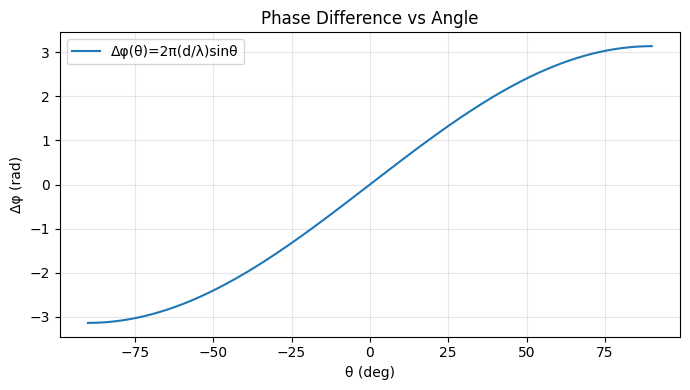

In [169]:
# Section 78: A) 理想阵列：steering vector 是“角度 → 相位模式”的映射
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### B) 漂移怎么建模：阵列缺陷导致 $a(\theta)$ 变成“受扰版本”

论文里用两类缺陷叠加来模拟漂移：

1) **距离失调（distance miscalibration）**：阵元位置/等效间距偏差

$$
\delta_n\sim U(-\eta,\eta),\quad \eta\in\{0.3,0.9,1.2\}.
$$

它会进入相位项，使 $d_n$ 变为 $d_n+\delta_n$：

$$
e^{-j\frac{2\pi}{\lambda}(d_n+\delta_n)\sin\theta}.
$$

2) **几何噪声（geometric noise）**：对 steering entry 的额外加性扰动

$$
\epsilon_{n,\theta}\sim \mathcal{CN}(0,0.9).
$$

综合后得到受扰 steering（论文式 (6) 的语义）：

$$
[a(\theta)]^{\star}_n
= e^{-j\frac{2\pi}{\lambda}(d_n+\delta_n)\sin\theta} + \epsilon_{n,\theta}.
$$


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1481324322.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


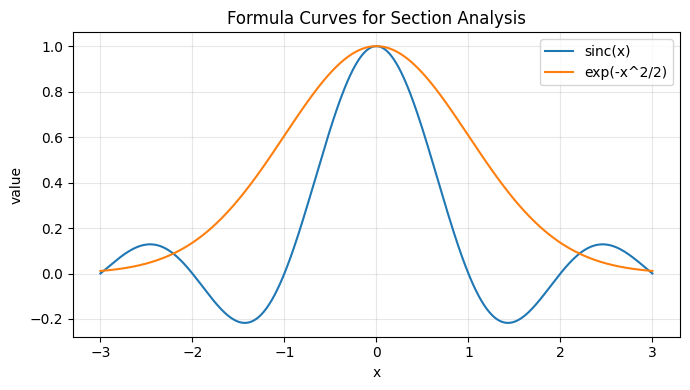

In [170]:
# Section 79: B) 漂移怎么建模：阵列缺陷导致 $a(\theta)$ 变成“受扰版本”
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### C) 为什么这就是 distribution shift？

训练（或理想仿真）时观测模型是：

$$
X = A_{\text{ideal}}(\theta)S + V,
$$

漂移发生后变为：

$$
X = A_{\text{perturbed}}(\theta)S + V.
$$

即使 $\theta$ 不变，只要 $A(\theta)$ 变了，同一个角度对应的“空间特征/相位模式”就变了，于是 $X$ 的统计分布也会变。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2946396386.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


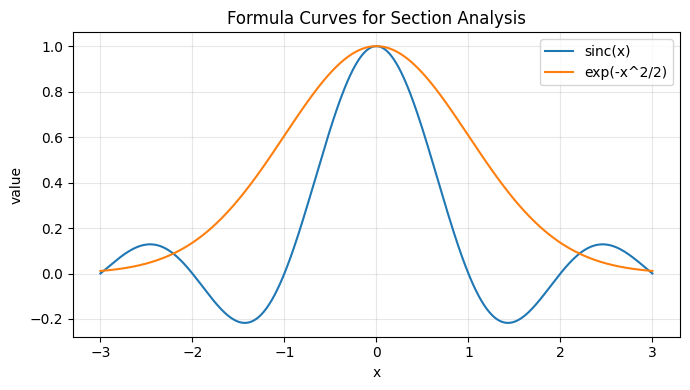

In [171]:
# Section 80: C) 为什么这就是 distribution shift？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 补充：为什么 $[a(\theta)]_n = e^{-j\frac{2\pi}{\lambda} d_n \sin\theta}$ 里会出现 $\sin\theta$？

直觉：它表达的是 **路径差 $\rightarrow$ 相位差**。

- 对窄带平面波，空间相位项可写成 $e^{-j\mathbf{k}^\top\mathbf{r}_n}$，其中 $|\mathbf{k}|=2\pi/\lambda$
- ULA 沿 $x$ 轴排布：$\mathbf{r}_n=[d_n,0,0]^\top$
- 若 $\theta$ 定义为相对 broadside（阵列法向）的偏转角，则波矢在 $x$ 方向的分量与 $\sin\theta$ 成正比，得到

$$
\mathbf{k}^\top\mathbf{r}_n = \frac{2\pi}{\lambda} d_n \sin\theta
\Rightarrow
[a(\theta)]_n = e^{-j\frac{2\pi}{\lambda} d_n \sin\theta}.
$$


Δφ range: -3.141592653589793 to 3.141592653589793


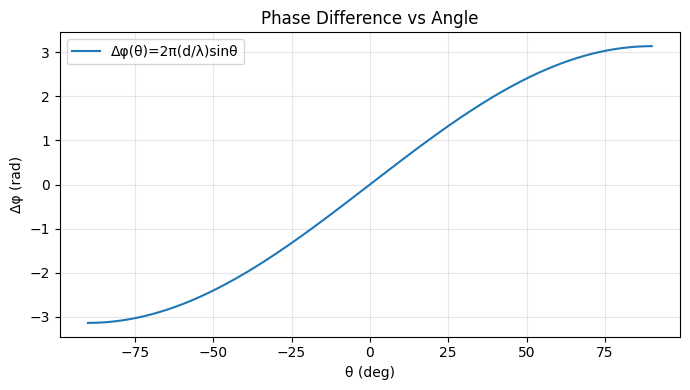

In [172]:
# Section 81: 补充：为什么 $[a(\theta)]_n = e^{-j\frac{2\pi}{\lambda} d_n \sin\theta}$ 里会出现 $\sin\theta$？
angles = np.linspace(-90, 90, 721)
theta = np.deg2rad(angles)
d_over_lambda = 0.5
delta_phi = 2*np.pi*d_over_lambda*np.sin(theta)
print('Δφ range:', float(delta_phi.min()), 'to', float(delta_phi.max()))
plt.figure(figsize=(7, 4))
plt.plot(angles, delta_phi, label='Δφ(θ)=2π(d/λ)sinθ')
plt.xlabel('θ (deg)')
plt.ylabel('Δφ (rad)')
plt.title('Phase Difference vs Angle')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 数值例子：$N=4,\ d=\lambda/2,\ \theta=30^\circ$

用相邻阵元路径差解释最直接：

1) 相邻路径差

$$
\Delta r = d\sin\theta = \frac{\lambda}{2}\cdot \sin 30^\circ = \frac{\lambda}{4}.
$$

2) 相邻相位差

$$
\Delta\phi = \frac{2\pi}{\lambda}\Delta r
= \frac{2\pi}{\lambda}\cdot \frac{\lambda}{4}
= \frac{\pi}{2}.
$$

3) steering vector（相对第 1 个阵元）

$$
[a(\theta)]_n = e^{-j(n-1)\Delta\phi}
\Rightarrow
a(30^\circ)=\begin{bmatrix}1\\-j\\-1\\j\end{bmatrix}.
$$

这也解释了为什么经典选择 $d=\lambda/2$：当 $\theta\in[-90^\circ,90^\circ]$ 时，$\Delta\phi=\pi\sin\theta\in[-\pi,\pi]$，相邻相位差不容易“绕圈”产生方向歧义（栅瓣/空间混叠风险更低）。


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1466318963.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


Signal energy (sinc^2 integral) = 0.9664


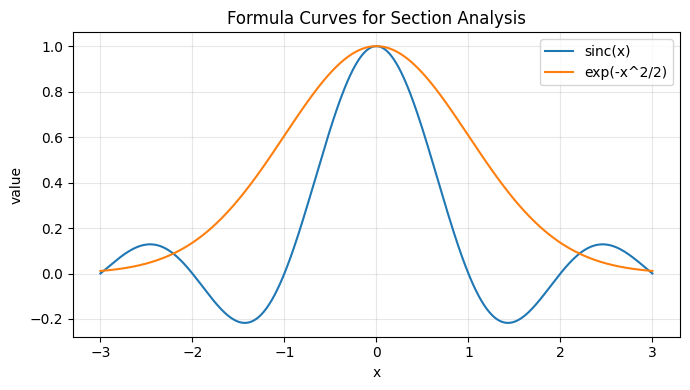

In [173]:
# Section 82: 数值例子：$N=4,\ d=\lambda/2,\ \theta=30^\circ$
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 复高斯（complex Gaussian）是什么？

“复高斯（complex Gaussian）”就是**取值在复平面上的高斯随机变量**。它不是“两个高斯凑一起”那么随意，而是有一套标准定义，主要用来建模通信/阵列里常见的 **I/Q（同相/正交）噪声**、热噪声、以及 steering vector 的随机扰动 $\epsilon_{n,\theta}$。

---


Estimated E|z|^2 = 0.8828369021207373


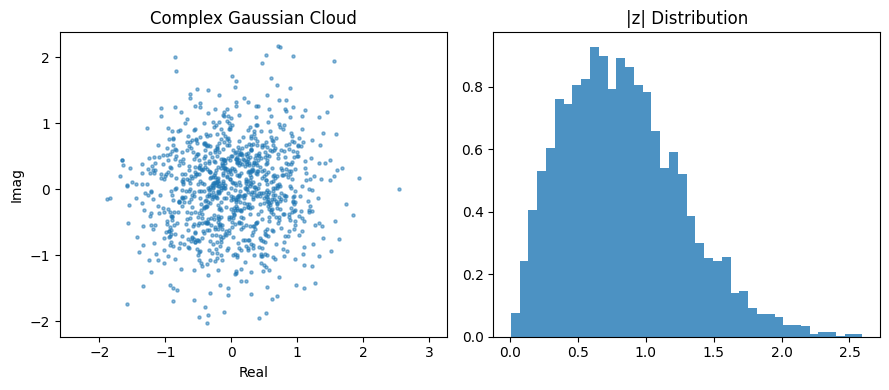

In [174]:
# Section 83: 复高斯（complex Gaussian）是什么？
sigma2 = 0.9
n = 4000
x = np.random.normal(0, np.sqrt(sigma2/2), n)
y = np.random.normal(0, np.sqrt(sigma2/2), n)
z = x + 1j*y
print('Estimated E|z|^2 =', np.mean(np.abs(z)**2))
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(np.real(z[:1000]), np.imag(z[:1000]), s=5, alpha=0.5)
ax[0].set_title('Complex Gaussian Cloud')
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Imag')
ax[0].axis('equal')
ax[1].hist(np.abs(z), bins=40, density=True, alpha=0.8)
ax[1].set_title('|z| Distribution')
plt.tight_layout()
plt.show()


### 1) 复高斯随机变量的定义

一个复随机变量写成：

$$
z = x + j y
$$

如果 $(x,y)$ 这对二维实随机变量**联合服从二维高斯分布**，就说 $z$ 是复高斯。

最常用、最“标准”的情况是 **圆对称复高斯**（circularly symmetric complex Gaussian）：

$$
z \sim \mathcal{CN}(0,\sigma^2)
$$

它等价于：

- $x \sim \mathcal{N}(0,\sigma^2/2)$
- $y \sim \mathcal{N}(0,\sigma^2/2)$
- $x$ 和 $y$ 相互独立（同方差）

直觉上：它在复平面上就是一个以 0 为中心的“圆形云团”，没有偏向任何方向，这就是“圆对称”的含义。

---


Estimated E|z|^2 = 0.8845749121344935


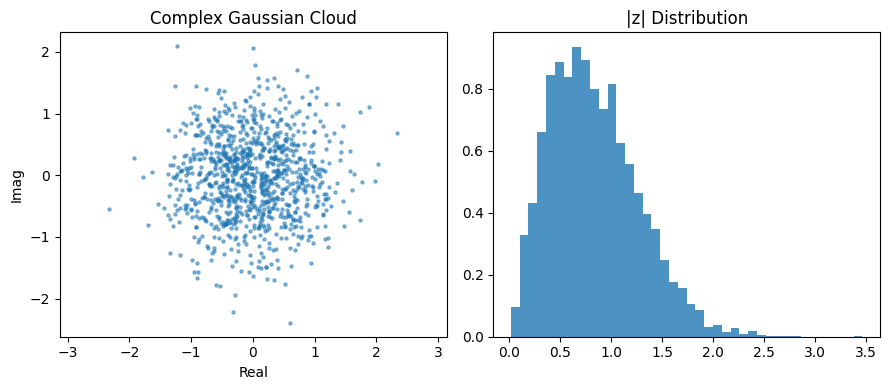

In [175]:
# Section 84: 1) 复高斯随机变量的定义
sigma2 = 0.9
n = 4000
x = np.random.normal(0, np.sqrt(sigma2/2), n)
y = np.random.normal(0, np.sqrt(sigma2/2), n)
z = x + 1j*y
print('Estimated E|z|^2 =', np.mean(np.abs(z)**2))
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(np.real(z[:1000]), np.imag(z[:1000]), s=5, alpha=0.5)
ax[0].set_title('Complex Gaussian Cloud')
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Imag')
ax[0].axis('equal')
ax[1].hist(np.abs(z), bins=40, density=True, alpha=0.8)
ax[1].set_title('|z| Distribution')
plt.tight_layout()
plt.show()


### 2) 复高斯里的“方差 $\sigma^2$”指什么？

对 $z\sim\mathcal{CN}(0,\sigma^2)$，这里的 $\sigma^2$ 指的是：

$$
\mathbb{E}[|z|^2] = \sigma^2
$$

并且实部、虚部各分摊一半：

$$
\mathbb{E}[x^2]=\mathbb{E}[y^2]=\sigma^2/2.
$$

---


Estimated E|z|^2 = 0.9102112088067231


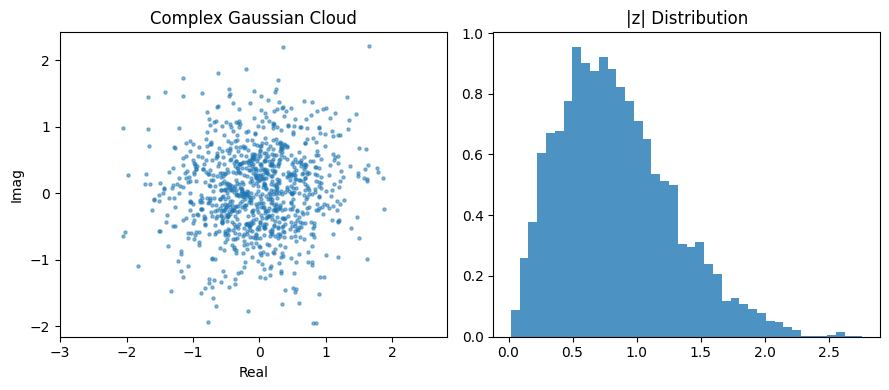

In [176]:
# Section 85: 2) 复高斯里的“方差 $\sigma^2$”指什么？
sigma2 = 0.9
n = 4000
x = np.random.normal(0, np.sqrt(sigma2/2), n)
y = np.random.normal(0, np.sqrt(sigma2/2), n)
z = x + 1j*y
print('Estimated E|z|^2 =', np.mean(np.abs(z)**2))
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(np.real(z[:1000]), np.imag(z[:1000]), s=5, alpha=0.5)
ax[0].set_title('Complex Gaussian Cloud')
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Imag')
ax[0].axis('equal')
ax[1].hist(np.abs(z), bins=40, density=True, alpha=0.8)
ax[1].set_title('|z| Distribution')
plt.tight_layout()
plt.show()


### 3) 概率密度长什么样？

若 $z\sim \mathcal{CN}(\mu,\sigma^2)$，其二维密度是：

$$
p(z)=\frac{1}{\pi\sigma^2}\exp\left(-\frac{|z-\mu|^2}{\sigma^2}\right).
$$

其中 $|z-\mu|^2=(x-\mu_x)^2+(y-\mu_y)^2$。分母里出现 $\pi\sigma^2$（而不是实高斯的 $\sqrt{2\pi\sigma^2}$），因为这是二维密度（复平面 = 2D）。

---


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/2217103667.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


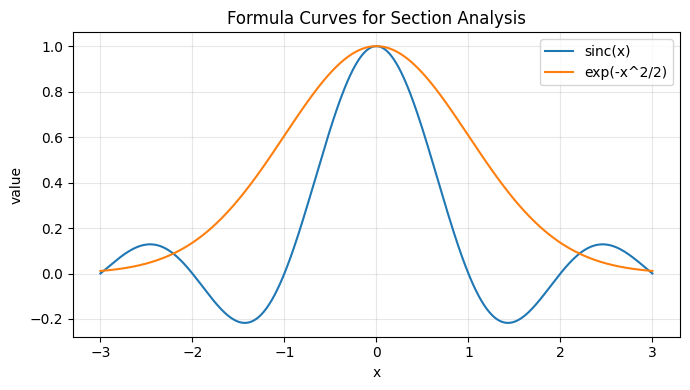

In [177]:
# Section 86: 3) 概率密度长什么样？
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 4) 为什么通信/阵列里特别常用复高斯？

很多噪声来自大量独立微小扰动的叠加（热噪声、散射、多径的随机叠加），按中心极限定理趋近高斯；同时信号处理常用复基带表示（I/Q），所以噪声自然写成复数形式并用复高斯建模。

---


Estimated E|z|^2 = 0.9106321798291895


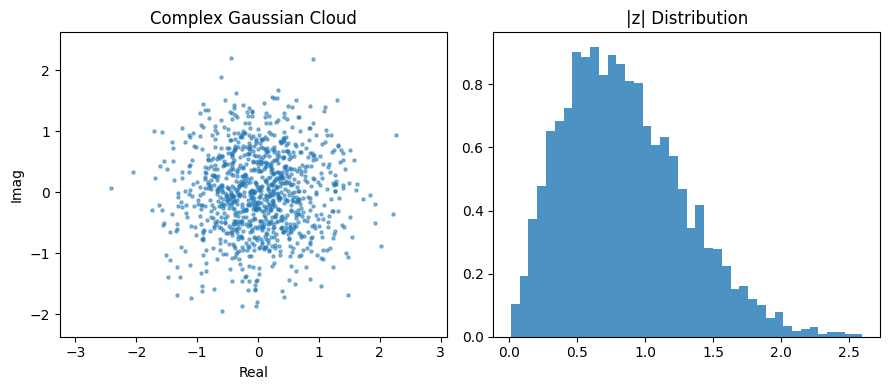

In [178]:
# Section 87: 4) 为什么通信/阵列里特别常用复高斯？
sigma2 = 0.9
n = 4000
x = np.random.normal(0, np.sqrt(sigma2/2), n)
y = np.random.normal(0, np.sqrt(sigma2/2), n)
z = x + 1j*y
print('Estimated E|z|^2 =', np.mean(np.abs(z)**2))
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(np.real(z[:1000]), np.imag(z[:1000]), s=5, alpha=0.5)
ax[0].set_title('Complex Gaussian Cloud')
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Imag')
ax[0].axis('equal')
ax[1].hist(np.abs(z), bins=40, density=True, alpha=0.8)
ax[1].set_title('|z| Distribution')
plt.tight_layout()
plt.show()


### 5) 回到论文：$\epsilon_{n,\theta}$ 的“复高斯扰动”意味着什么？

论文里把几何噪声建模为：

$$
\epsilon_{n,\theta}\sim\mathcal{CN}(0,0.9).
$$

意思是：对每个阵元 $n$（以及可能对每个角度 $\theta$ 或每次生成 steering 时），他们往理想 steering entry 上**加一个随机复数扰动**：

$$
[a(\theta)]^{\star}_n = e^{-j\frac{2\pi}{\lambda}(d_n+\delta_n)\sin\theta} + \epsilon_{n,\theta}.
$$

这会同时扰动：

- **幅度**（加性复数会改变模长）
- **相位**（会改变相角）

因此它不只是“相位偏一点”，而是 steering vector 的复值整体被污染，用来模拟阵列响应的非理想性。

---


Estimated E|z|^2 = 0.8942344174785668


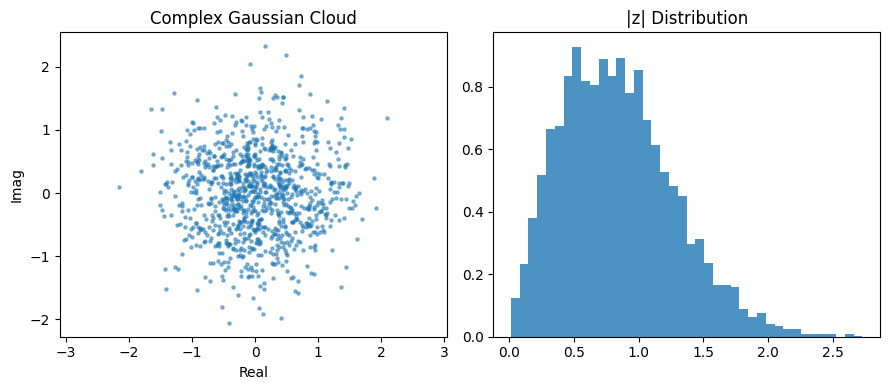

In [179]:
# Section 88: 5) 回到论文：$\epsilon_{n,\theta}$ 的“复高斯扰动”意味着什么？
sigma2 = 0.9
n = 4000
x = np.random.normal(0, np.sqrt(sigma2/2), n)
y = np.random.normal(0, np.sqrt(sigma2/2), n)
z = x + 1j*y
print('Estimated E|z|^2 =', np.mean(np.abs(z)**2))
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(np.real(z[:1000]), np.imag(z[:1000]), s=5, alpha=0.5)
ax[0].set_title('Complex Gaussian Cloud')
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Imag')
ax[0].axis('equal')
ax[1].hist(np.abs(z), bins=40, density=True, alpha=0.8)
ax[1].set_title('|z| Distribution')
plt.tight_layout()
plt.show()


### 6) 一个很直观的采样方式

如果要在仿真里生成 $z\sim\mathcal{CN}(0,\sigma^2)$，常用做法：

- 采 $x\sim\mathcal{N}(0,\sigma^2/2)$
- 采 $y\sim\mathcal{N}(0,\sigma^2/2)$
- 令 $z=x+j y$

对论文里的 $\sigma^2=0.9$，就是 $x,y$ 的方差各为 $0.45$。

> 如果后续需要更深入：还可以继续补充“非圆对称复高斯”（会涉及 pseudo-variance / impropriety）以及为什么很多通信论文默认使用圆对称 $\mathcal{CN}(0,\sigma^2)$。


Signal energy (sinc^2 integral) = 0.9664


/var/folders/83/j6l7_w4x2bdg4ms_fzfwcv3h0000gn/T/ipykernel_94441/1793764254.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(np.abs(y1)**2, x)


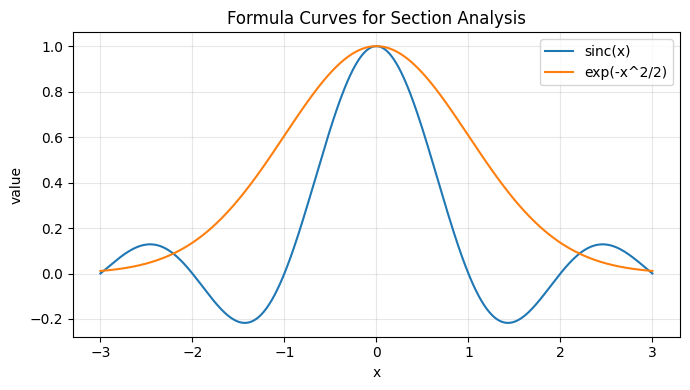

In [180]:
# Section 89: 6) 一个很直观的采样方式
x = np.linspace(-3, 3, 600)
y1 = np.sinc(x)
y2 = np.exp(-0.5*x**2)
energy = np.trapz(np.abs(y1)**2, x)
print('Signal energy (sinc^2 integral) =', round(float(energy), 4))
plt.figure(figsize=(7, 4))
plt.plot(x, y1, label='sinc(x)')
plt.plot(x, y2, label='exp(-x^2/2)')
plt.title('Formula Curves for Section Analysis')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
